In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4,
          'xtick.minor.visible': True,
          'ytick.minor.visible': True,}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [2]:
dco_types = const.DCO_TYPES.copy()
for i in range(len(dco_types)):
    dco_types.append(f"{dco_types[i]}_pessimistic")

In [3]:
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_in_band.h5") for dco_type in dco_types
}

In [4]:
for dco_type in dco_types:
    pop = pops[dco_type]
    print(dco_type)
    pop.final_pos, pop.final_vel

BHBH
BHNS
BHWD
NSNS
NSWD
BHBH_pessimistic
BHNS_pessimistic
BHWD_pessimistic
NSNS_pessimistic
NSWD_pessimistic


In [5]:
detectable_pops = {}
for dco_type in dco_types:
    mask = (
        (pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_lisa_8yr_initial_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_initial_pos"] > 12)
    )
    detectable_pops[dco_type] = pops[dco_type][mask]

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y

In [6]:
detectable_sources = {}
for dco_type in dco_types:
    print(dco_type)
    path = f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_detectable_sources.h5"
    if os.path.isfile(path):
        detectable_sources[dco_type] = lw.source.Source.from_file(path)
    else:
        # turn them into a LEGWORK source class
        detectable_sources[dco_type] = detectable_pops[dco_type].to_legwork_sources(assume_mw_galactocentric=True)
        detectable_sources[dco_type].n_proc = 30

        # find those that haven't reached RLOF yet evolve them via GWs until present day
        if "rlof_time" not in detectable_pops[dco_type].bpp.columns:
             detectable_pops[dco_type].bpp["rlof_time"] = 1e20

        reached_rlof = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr

        non_rlof_sources = detectable_sources[dco_type][~reached_rlof]
        non_rlof_sources.evolve_sources(t_evol=detectable_pops[dco_type].initial_galaxy.tau[~reached_rlof] - detectable_pops[dco_type].bpp["tphys"].values[~reached_rlof] * u.Myr)

        # recombine into a single source class
        detectable_sources[dco_type].m_1[~reached_rlof] = non_rlof_sources.m_1
        detectable_sources[dco_type].m_2[~reached_rlof] = non_rlof_sources.m_2
        detectable_sources[dco_type].dist[~reached_rlof] = non_rlof_sources.dist
        detectable_sources[dco_type].ecc[~reached_rlof] = non_rlof_sources.ecc
        detectable_sources[dco_type].f_orb[~reached_rlof] = non_rlof_sources.f_orb
        detectable_sources[dco_type].merged[~reached_rlof] = non_rlof_sources.merged

        detectable_sources[dco_type].save(path, overwrite=True)

BHBH
BHNS


BHWD
NSNS
NSWD
BHBH_pessimistic
BHNS_pessimistic
BHWD_pessimistic
NSNS_pessimistic
NSWD_pessimistic


# Spatial plots

In [12]:
lisa_pops = {dco_type: detectable_pops[dco_type + "_pessimistic"][detectable_pops[dco_type + "_pessimistic"].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}
lisa_sources = {dco_type: detectable_sources[dco_type + "_pessimistic"][detectable_pops[dco_type + "_pessimistic"].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}

In [ ]:
fig, ax = plt.subplots()
ax.hexbin(
    pop.final_pos[:, 0][pop.bpp["snr_lisa_10yr_final_pos"] > 7], pop.final_pos[:, 1][pop.bpp["snr_lisa_10yr_final_pos"] > 7],
    C=pop.initC["weights"][pop.bpp["snr_lisa_10yr_final_pos"] > 7],
    reduce_C_function=np.sum,
    extent=(-30, 30, -30, 30), bins="log", gridsize=100, cmap="magma"
)

radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=10)
    ax.add_artist(circle)

ax.set(
    xlim=(-30, 30), ylim=(-30, 30), xlabel="X [kpc]", ylabel="Y [kpc]",
    aspect="equal"
)
plt.show()

In [8]:
from scipy.ndimage import gaussian_filter


def weighted_contour_levels(H, fractions):
    """Find the contour levels enclosing given fractions of the total weight.

    Parameters
    ----------
    H : `numpy.ndarray`
        2D array of binned weights.
    fractions : `list` of `float`
        Fractions of the total weight to enclose, e.g. ``[0.5, 0.9]``.

    Returns
    -------
    levels : `numpy.ndarray`
        Contour levels in increasing order.
    """
    flat = np.sort(H.ravel())[::-1]
    cumulative = np.cumsum(flat)
    cumulative /= cumulative[-1]

    # the level at which the running total first passes each target fraction
    inds = np.searchsorted(cumulative, fractions)
    levels = flat[np.clip(inds, 0, len(flat) - 1)]
    return np.unique(levels)


def add_enclosing_contours(ax, x, z, weights, extent, bins=80, smooth=1.5,
                           fractions=(0.5, 0.9), **kwargs):
    """Overlay contours enclosing fractions of the weight on a single side of a panel.

    Parameters
    ----------
    ax : `matplotlib.axes.Axes`
        Axes on which to draw.
    x, z : `numpy.ndarray`
        Positions of each binary.
    weights : `numpy.ndarray`
        Weight of each binary.
    extent : `tuple`
        Bounds as ``(x_min, x_max, z_min, z_max)``.
    bins : `int`
        Number of bins per dimension used to estimate the density.
    smooth : `float`
        Standard deviation of the Gaussian smoothing kernel, in bins.
    fractions : `tuple` of `float`
        Fractions of the total weight to enclose.

    Returns
    -------
    contours : `matplotlib.contour.QuadContourSet`
        The contour set that was drawn.
    """
    H, x_edges, z_edges = np.histogram2d(x, z, bins=bins, weights=weights,
                                         range=[extent[:2], extent[2:]])

    # transpose so that rows run along z, as contour expects
    H = gaussian_filter(H.T, smooth)

    x_cent = 0.5 * (x_edges[1:] + x_edges[:-1])
    z_cent = 0.5 * (z_edges[1:] + z_edges[:-1])

    levels = weighted_contour_levels(H, sorted(fractions, reverse=True))
    return ax.contour(x_cent, z_cent, H, levels=levels, **kwargs)

BHBH: Scale height increases by 3.0x
BHNS: Scale height increases by 6.9x
BHWD: Scale height increases by 1.6x
NSNS: Scale height increases by 4.2x
NSWD: Scale height increases by 2.7x


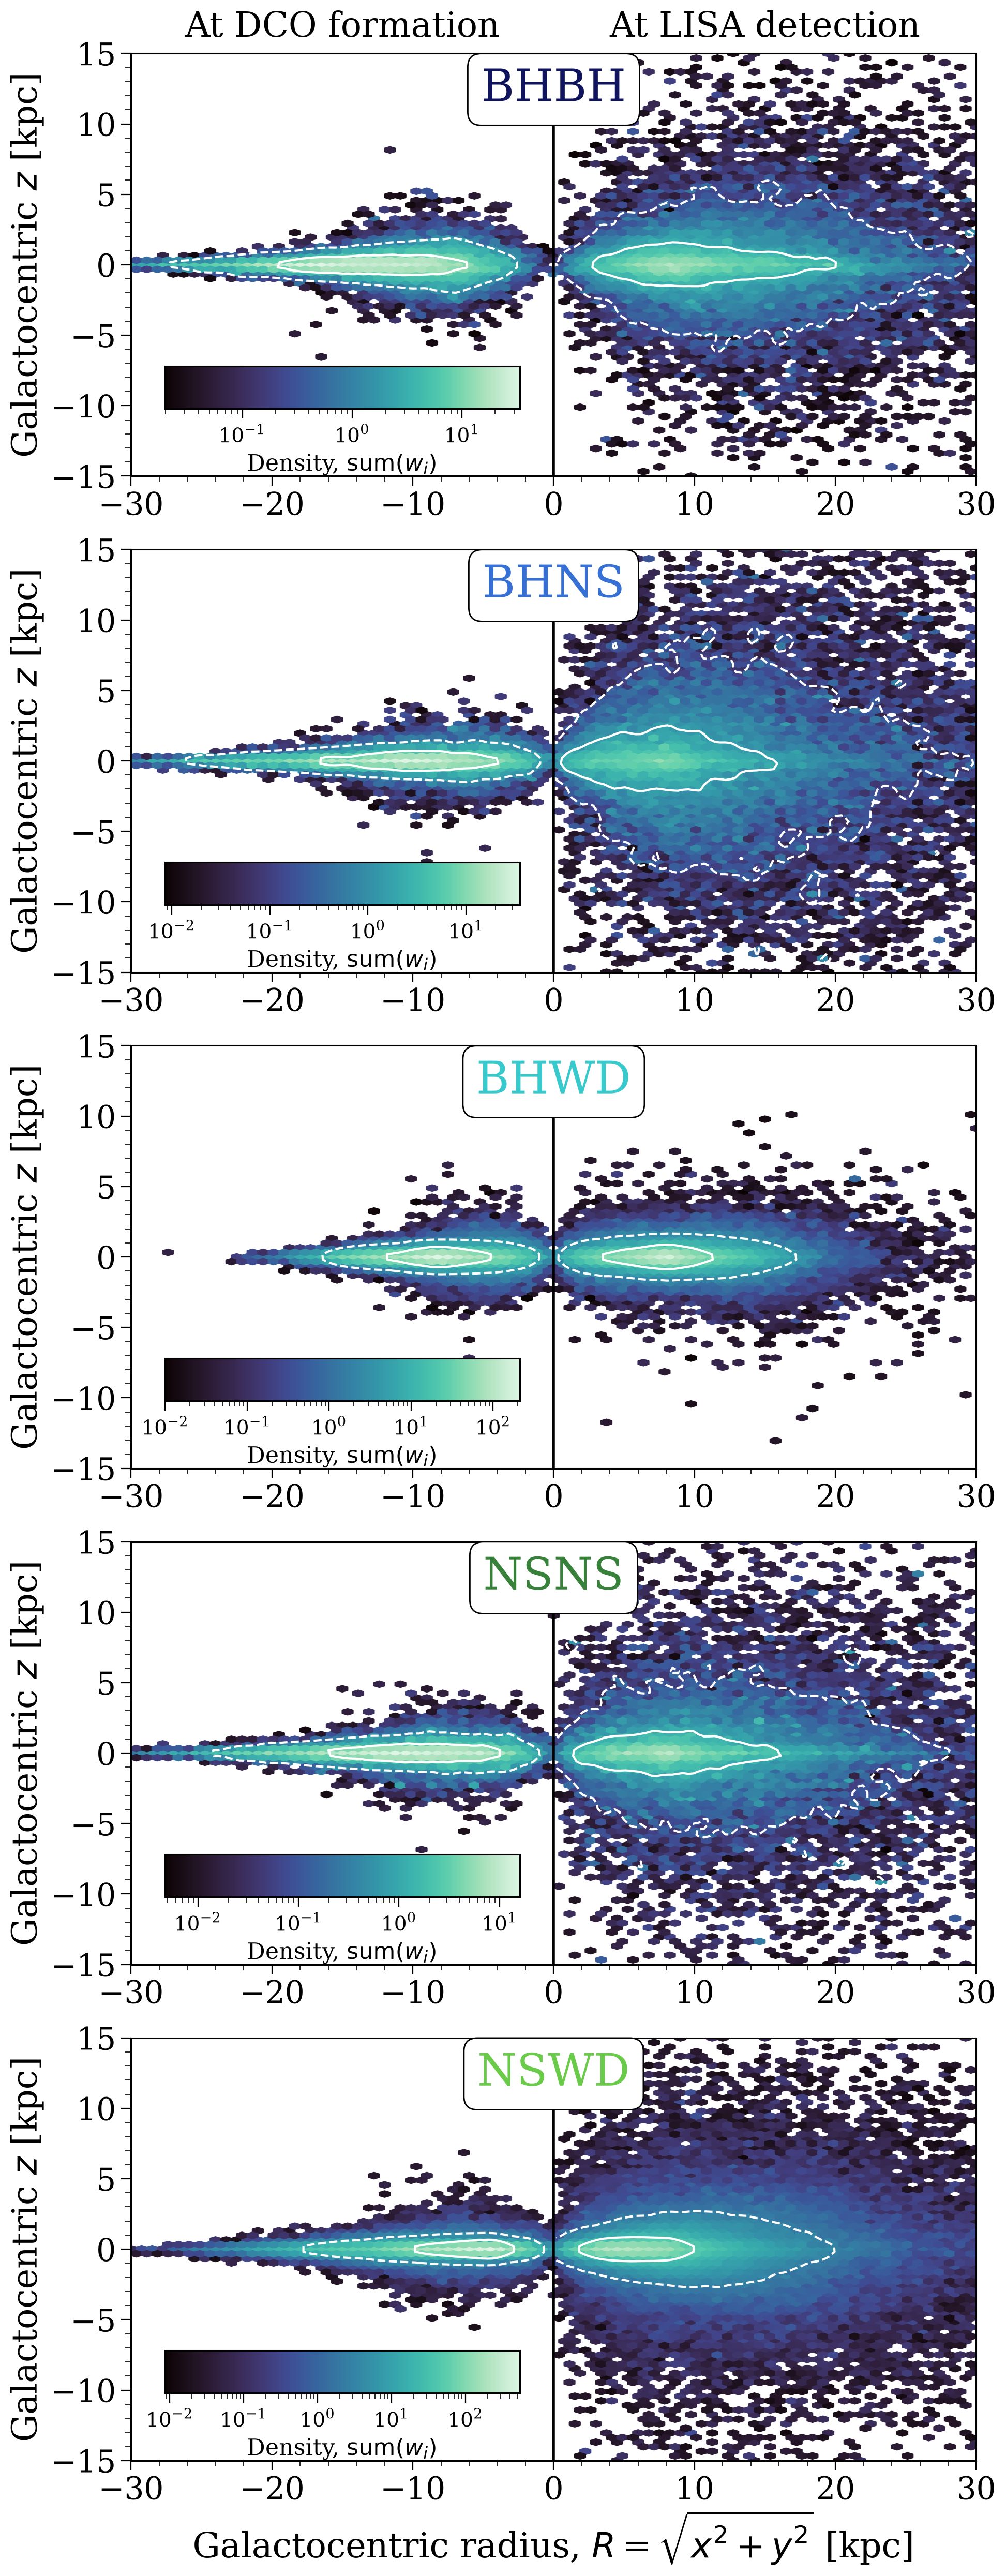

In [13]:
reload(plotting)
fig, axes = plt.subplots(5, 1, figsize=(14, 25), layout="tight")

Z_MAX = 15

for ax, dco_type in zip(axes, const.DCO_TYPES):
    # stack formation and detection epochs so they share a single norm
    pop = lisa_pops[dco_type]
    w = pop.bpp["weights"].values

    # left half at formation, right half at detection
    sides = [(-pop.initial_galaxy.rho.value, pop.initial_galaxy.z.value, (-30, 0, -Z_MAX, Z_MAX)),
             (np.linalg.norm(pop.final_pos[:, :2].value, axis=1), pop.final_pos[:, 2].value, (0, 30, -Z_MAX, Z_MAX))]

    scale_heights = [plotting.estimate_scale_height_cdf(side[1], weights=w) for side in sides]
    print(f"{dco_type}: Scale height increases by {scale_heights[1] / scale_heights[0]:1.1f}x")

    # stack the epochs so they share a single norm
    hexbin = ax.hexbin(np.concatenate([s[0] for s in sides]),
                       np.concatenate([s[1] for s in sides]),
                       C=np.concatenate([w, w]), reduce_C_function=np.sum,
                       extent=(-30, 30, -Z_MAX, Z_MAX), gridsize=80,
                       bins="log", cmap=sns.color_palette("mako", as_cmap=True), rasterized=True)

    for x, z, extent in sides:
        add_enclosing_contours(ax, x, z, w, extent, colors="w",
                               linestyles=["--", "-"], linewidths=1.5, smooth=1)

    inset_ax = ax.inset_axes([0.04, 0.16, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    # ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    # ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    # ax.annotate(dco_type, xy=(0.5, 0.98), xycoords="axes fraction", ha='center', va="top", fontsize=1.3*fs, rotation=0, color=const.DCO_COLOURS[dco_type],
    #             bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", pad=0.0))
    ax.annotate(dco_type, xy=(0.5, 0.9275), xycoords="axes fraction", ha='center', va="center_baseline", fontsize=1.3*fs, color=const.DCO_COLOURS[dco_type],
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    ax.set(
        ylabel=r"Galactocentric $z$ [kpc]", xlim=(-30, 30), ylim=(-Z_MAX, Z_MAX), aspect="equal"
    )
    # break

axes[0].annotate("At DCO formation", xy=(0.25, 1.02), xycoords="axes fraction", ha='center', va="bottom", fontsize=fs)
axes[0].annotate("At LISA detection", xy=(0.75, 1.02), xycoords="axes fraction", ha='center', va="bottom", fontsize=fs)

axes[-1].set_xlabel(r"Galactocentric radius, $R = \sqrt{x^2 + y^2}$ [kpc]")

plt.savefig("../plots/dco_positions.pdf", bbox_inches="tight")

plt.show()

BHBH [np.float64(0.4289025162475652), np.float64(1.3078663272671094)] 3.0493323720959493
BHNS [np.float64(0.320277643703449), np.float64(2.2229535416317514)] 6.940707805662593
BHWD [np.float64(0.2726152435128306), np.float64(0.4271449230679444)] 1.5668416687339086
NSNS [np.float64(0.331800955434606), np.float64(1.402741121145205)] 4.227658474665448
NSWD [np.float64(0.20000546339440686), np.float64(0.5431394667093167)] 2.7156231509449134


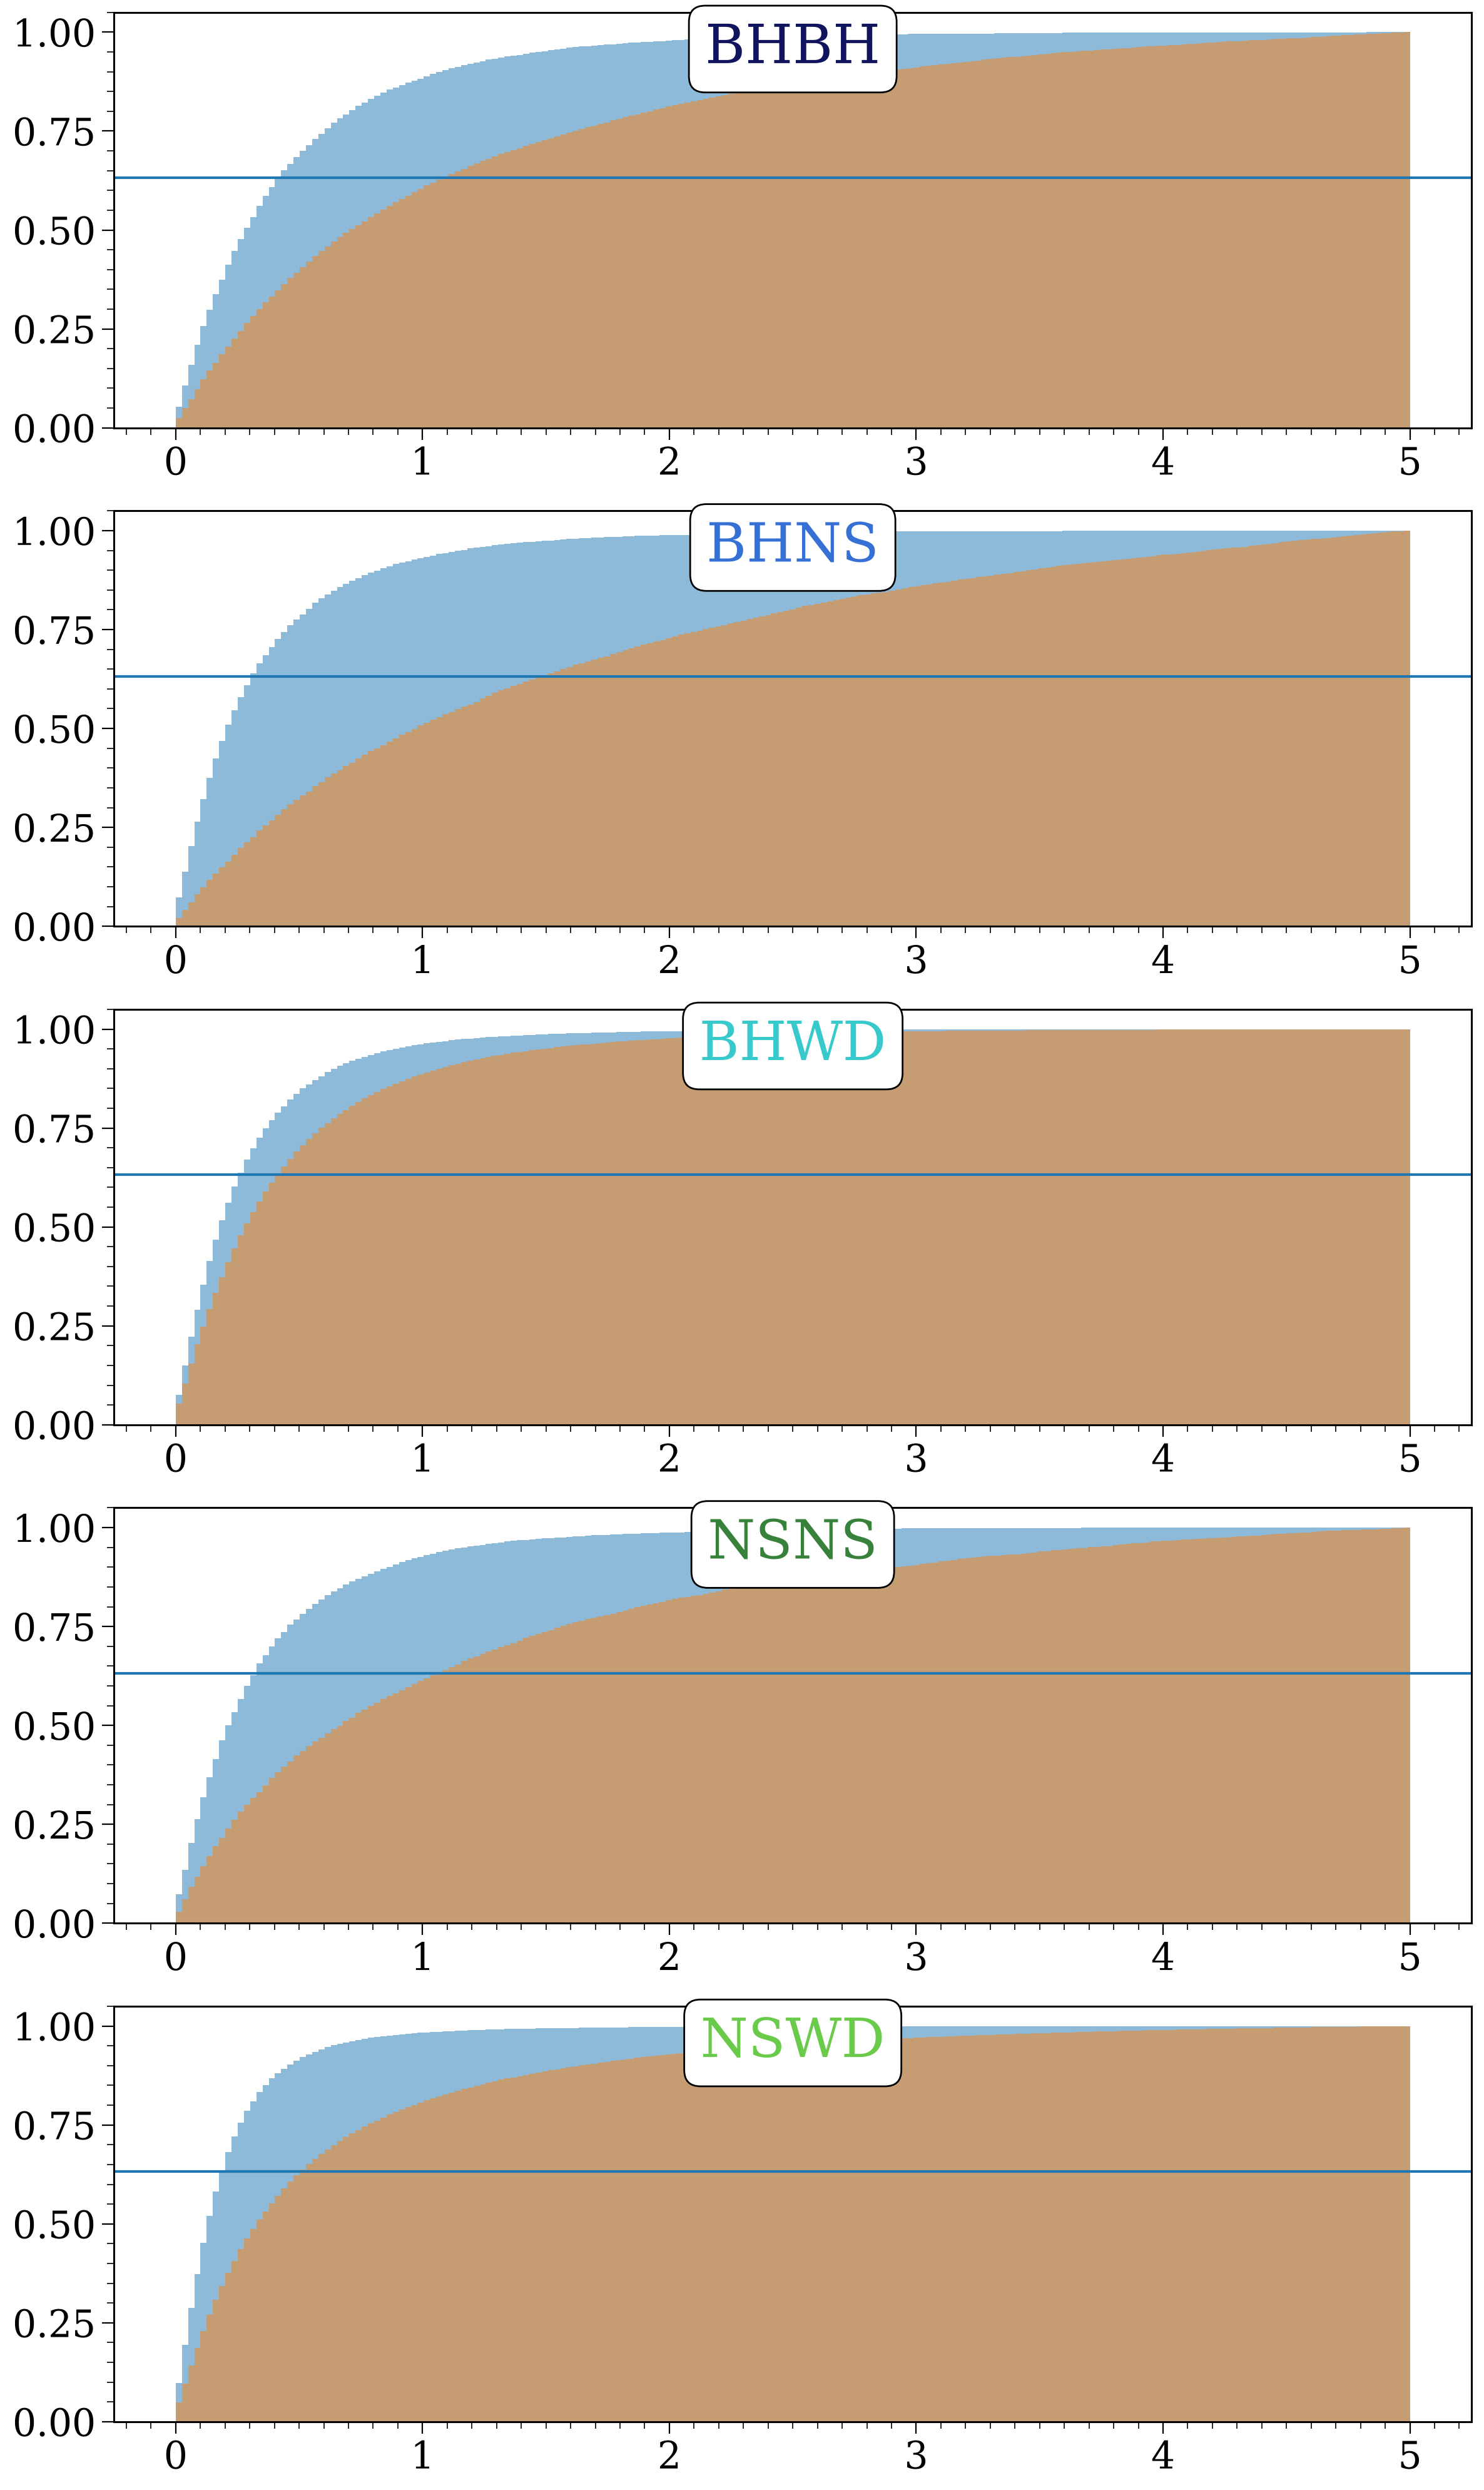

In [14]:
reload(plotting)
fig, axes = plt.subplots(5, 1, figsize=(14, 25))

for ax, dco_type in zip(axes, const.DCO_TYPES):
    # stack formation and detection epochs so they share a single norm
    pop = lisa_pops[dco_type]
    w = pop.bpp["weights"].values

    scale_heights = []
    for z in [pop.initial_galaxy.z.value, pop.final_pos[:, 2].value]:
        scale_heights.append(plotting.estimate_scale_height_cdf(z, weights=w))
        
        ax.hist(np.abs(z), weights=w, bins=np.linspace(0, 5, 200), alpha=0.5, density=True, cumulative=True)
    print(dco_type, scale_heights, scale_heights[1] / scale_heights[0])
    ax.annotate(dco_type, xy=(0.5, 0.9275), xycoords="axes fraction", ha='center', va="center_baseline", fontsize=1.3*fs, color=const.DCO_COLOURS[dco_type],
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))
    ax.axhline(1 - 1/np.e)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))

# plt.savefig("../plots/dco_positions.pdf", bbox_inches="tight")

plt.show()

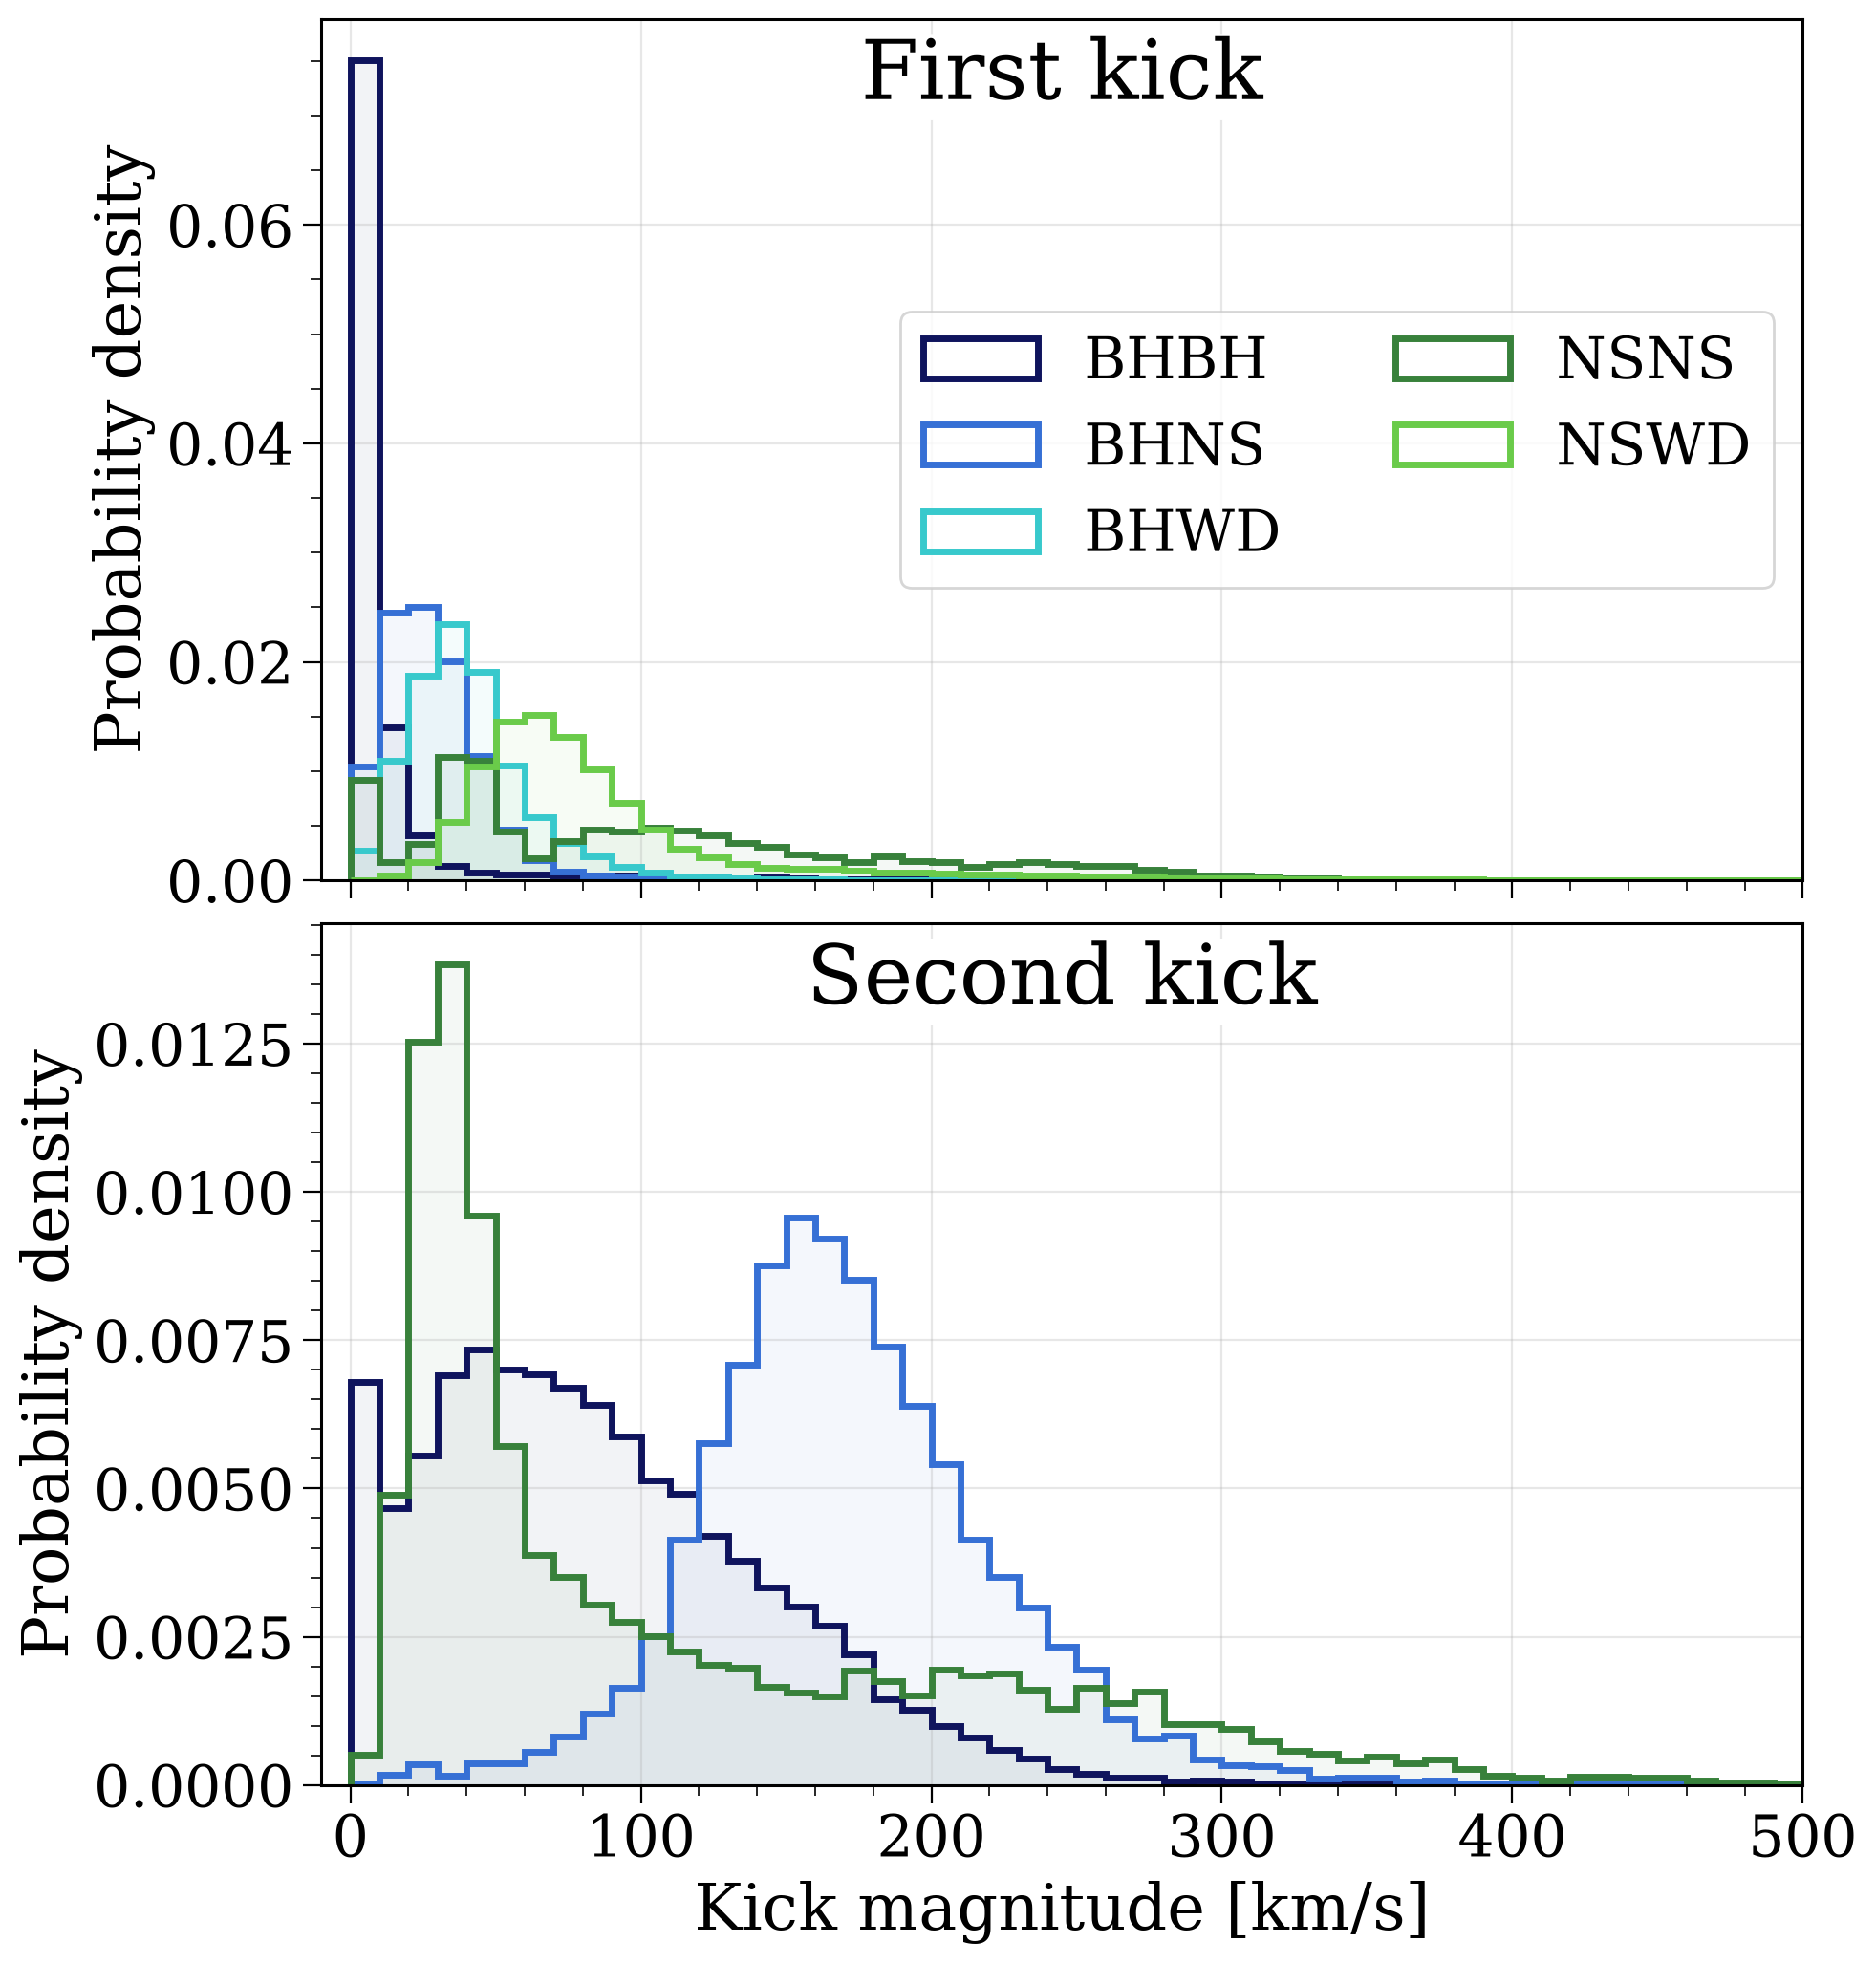

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

fig.subplots_adjust(hspace=0.05)

for dco_type in const.DCO_TYPES:
    kick_info = lisa_pops[dco_type].kick_info

    kick_info = kick_info[kick_info["star"] != 0]
    
    # groupby bin_num and separate into a row with the lowest tphys col and a row with the highest tphys col, then calculate the magnitude of the kick for each row
    first_kick = kick_info.sort_values(by="tphys").drop_duplicates(subset="bin_num", keep="first")
    second_kick = kick_info.sort_values(by="tphys").drop_duplicates(subset="bin_num", keep="last")

    first_kick_mag = np.linalg.norm(first_kick[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]].values, axis=1)
    second_kick_mag = np.linalg.norm(second_kick[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]].values, axis=1)

    bins = np.linspace(0, 500, 51)
    alpha = 0.05
    plotting.nice_transparent_hist(ax=axes[0], data=first_kick_mag, weights=lisa_pops[dco_type].bpp["weights"], bins=bins, label=f"{dco_type}", colour=const.DCO_COLOURS[dco_type], density=True, alpha=alpha, lw=2.5)

    if "WD" not in dco_type:
        plotting.nice_transparent_hist(ax=axes[1], data=second_kick_mag, weights=lisa_pops[dco_type].bpp["weights"], bins=bins, label=f"{dco_type}", colour=const.DCO_COLOURS[dco_type], density=True, alpha=alpha, lw=2.5)
    # axes[0].set_yscale("log")
    # axes[1].set_yscale("log")
axes[0].legend(loc="center right", ncol=2, fontsize=0.9*fs)
# axes[0].set_ylim(top=0.04)
    
axes[0].annotate("First kick", xy=(0.5, 0.98), xycoords="axes fraction", ha='center', va="top", fontsize=1.3*fs, color="k", bbox=dict(boxstyle="round", facecolor="white", edgecolor="white", pad=0.0))
axes[1].annotate("Second kick", xy=(0.5, 0.98), xycoords="axes fraction", ha='center', va="top", fontsize=1.3*fs, color="k", bbox=dict(boxstyle="round", facecolor="white", edgecolor="white", pad=0.0))

for ax in axes:
    ax.set_ylabel("Probability density")
    ax.grid(alpha=0.3)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(20))
    ax.set_xlim(-10, 500)

axes[1].set_xlabel("Kick magnitude [km/s]")

plt.savefig("../plots/kick_magnitudes_two_panels.pdf", bbox_inches="tight")
plt.show()

# LISA source plots

BHWD has 1.00 of sources with e == 0, not plotting
NSWD has 0.98 of sources with e == 0, not plotting


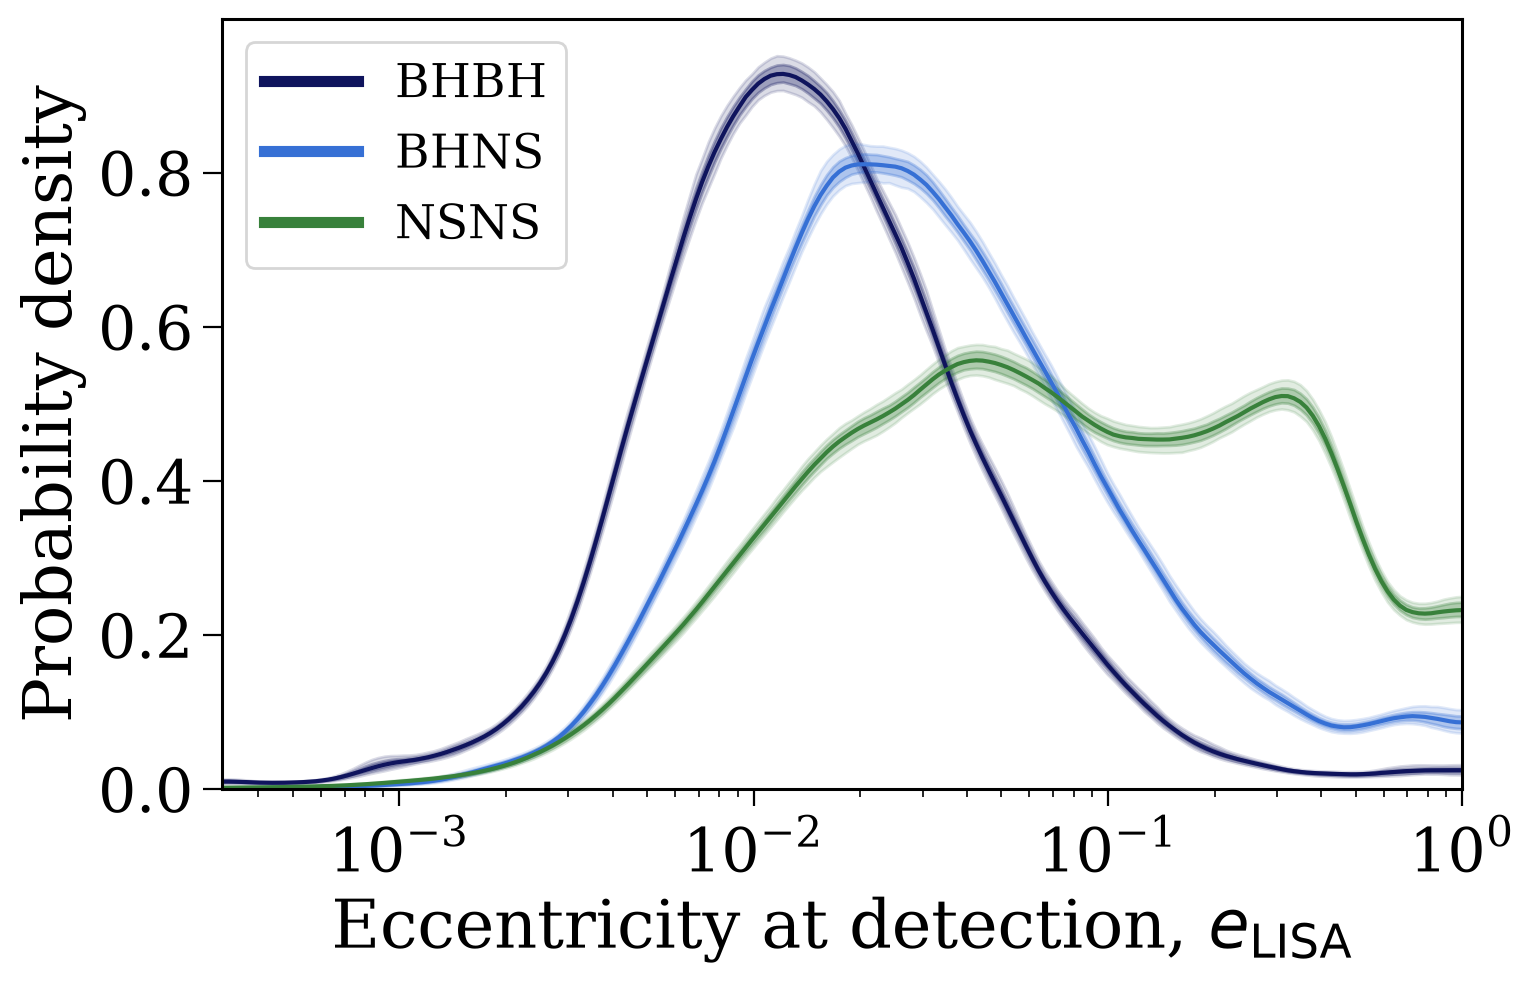

In [16]:
reload(plotting)

fig, ax = plt.subplots(figsize=(8, 5))

for dco_type in const.DCO_TYPES:
    s = detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    w = lisa_4yr_pops[dco_type].initC["weights"]
    circ = s.ecc == 0
    f_circ = np.sum(w[circ]) / np.sum(w)
    if f_circ > 0.9:
        print(f"{dco_type} has {f_circ:.2f} of sources with e == 0, not plotting")
        continue
    
    elif f_circ > 0.01:
        print(f"Warning that {dco_type} has {f_circ:.2f} of sources with e == 0, plotting anyway")
    # plt.hist(np.log10(s.ecc), bins=np.linspace(-4, 0, 100), weights=w, label=dco_type, histtype="step", lw=2.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.ecc[~circ]), weights=w.values[~circ], ax=ax, upper_bound=0, x_min=-3.5, x_max=0, bootstraps=500, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

plotting.fake_log_axis(ax, axis="x")

handles, labels = ax.get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(4)
ax.legend(handles, labels, loc="upper left")

ax.set(
    xlabel=r"Eccentricity at detection, $e_{\rm LISA}$",
    ylabel=r"Probability density",
    xlim=(-3.5, 0),
    ylim=(0, None)
)

plt.savefig("../plots/e_lisa.pdf", bbox_inches="tight")

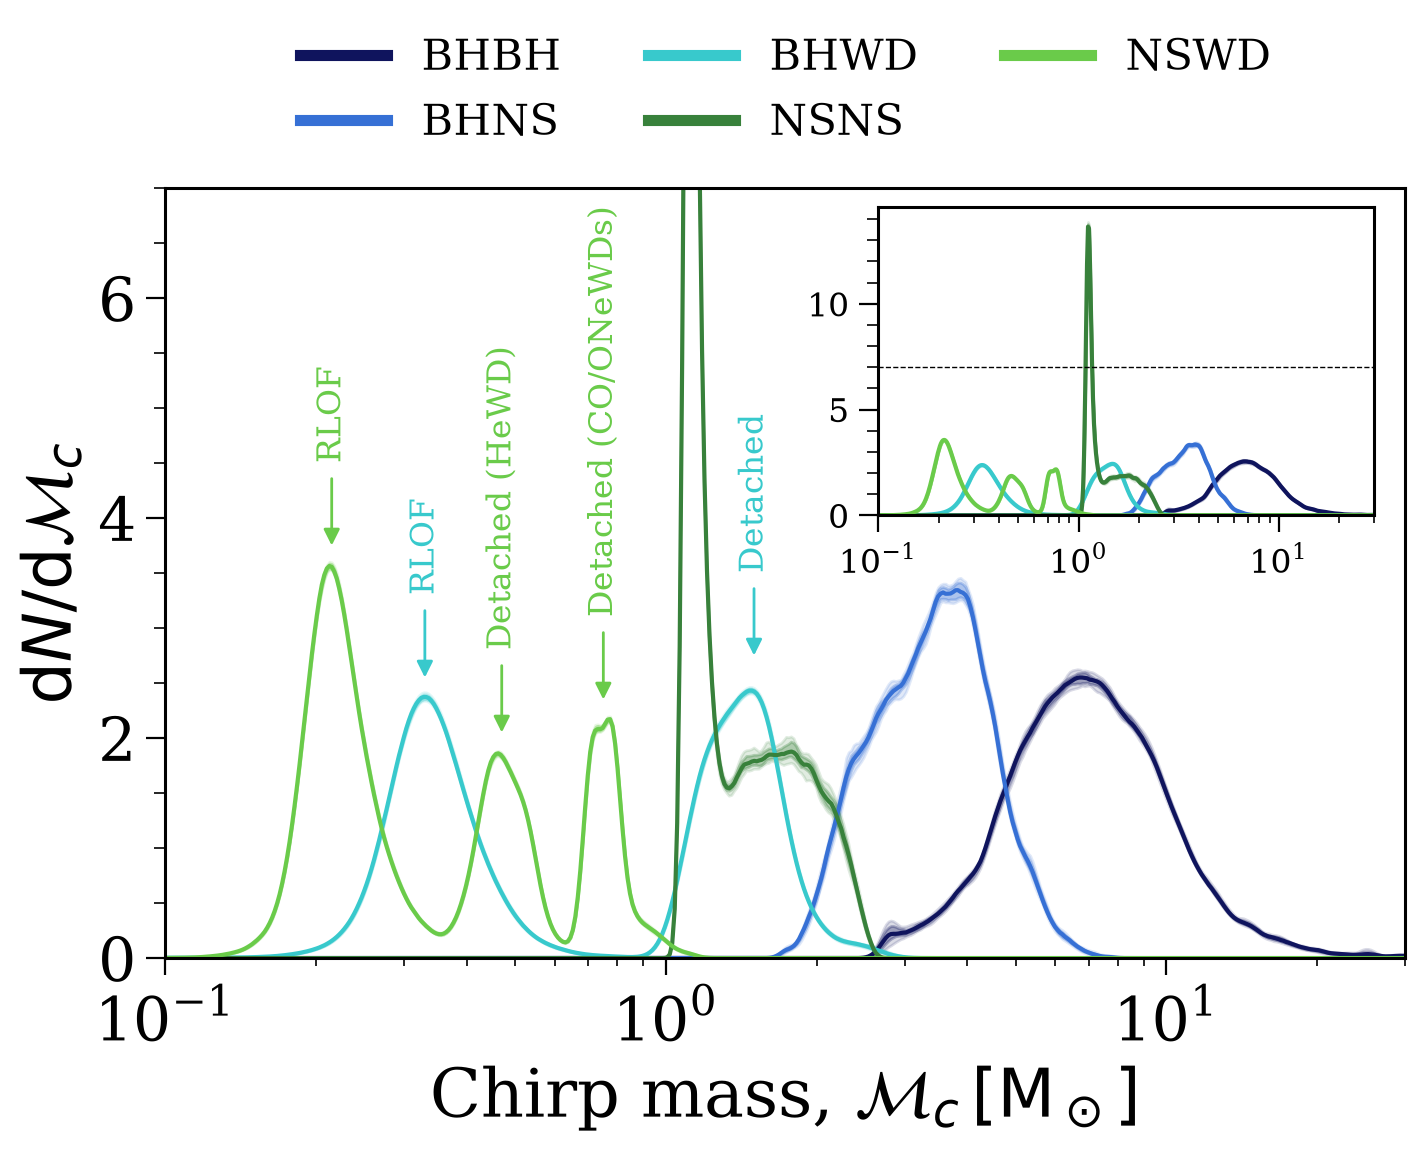

In [103]:
reload(plotting)

fig, ax = plt.subplots(figsize=(8, 5))

inset_ax = ax.inset_axes([0.575, 0.575, 0.4, 0.4])

for dco_type in const.DCO_TYPES:
    s = detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    w = lisa_4yr_pops[dco_type].initC["weights"]
    # plt.hist(np.log10(s.m_c.value), bins=np.linspace(np.log10(0.1), np.log10(30), 200), weights=w, label=dco_type, histtype="step", lw=0.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.m_c.value), weights=w.values, ax=[ax, inset_ax], x_min=np.log10(0.1), x_max=np.log10(30),
        bootstraps=50, x_count=500, bw_adjust=0.75, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

    # total = np.sum(w)
    # rlof_mask = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr
    # if rlof_mask.sum() > 0:
    #     s = detectable_sources[dco_type][(detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7) & rlof_mask]
    #     w = detectable_pops[dco_type].bpp[(detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7) & rlof_mask]["weights"]
    #     plotting.bootstrapped_kde_fast(
    #         variable=np.log10(s.m_c.value), weights=w.values, ax=ax, x_min=np.log10(0.1), x_max=np.log10(30), bootstraps=50, x_count=500, bw_adjust=0.5, color="black", label=dco_type,
    #         normalisation=np.sum(w) / total
    #     )

plotting.fake_log_axis(ax, axis="x")
plotting.fake_log_axis(inset_ax, axis="x")

handles, labels = ax.get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(4)
ax.legend(handles, labels, loc="lower center", ncol=3, fontsize=0.65*fs, bbox_to_anchor=(0.5, 1.005), frameon=False)

annotations = [
    (0.215, 3.7,  "RLOF", const.DCO_COLOURS["NSWD"]),
    (0.47, 2, "Detached (HeWD)", const.DCO_COLOURS["NSWD"]),
    (0.75, 2.3, "Detached (CO/ONeWDs)", const.DCO_COLOURS["NSWD"]),
    (0.33, 2.5, "RLOF", const.DCO_COLOURS["BHWD"]),
    (1.5, 2.7, "Detached", const.DCO_COLOURS["BHWD"]),
]

for x, y, text, color in annotations:
    ax.annotate(text, xy=(np.log10(x), y), xytext=(np.log10(x), y + 0.8), xycoords="data", ha='center', va="bottom",
                fontsize=0.5*fs, color=color, rotation=90,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="none"),
                arrowprops=dict(arrowstyle="-|>", color=color))

ax.set(
    xlabel=r"Chirp mass, $\mathcal{M}_c \, [\rm {M_\odot}]$",
    ylabel=r"${\rm d}N / {\rm d} \mathcal{M}_c$",
    xlim=(-1, np.log10(30)),
    ylim=(0, 7),
    # yscale="log",
    # ylim=(1e-1, 2e1)
)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))

inset_ax.set(
    xlim=(-1, np.log10(30)),
    ylim=(0, None)
)
inset_ax.axhline(7, color="k", ls="--", lw=0.5)
inset_ax.tick_params(axis="both", which="both", labelsize=0.5*fs)
inset_ax.yaxis.set_minor_locator(plt.MultipleLocator(1))

plt.savefig("../plots/m_chirp_lisa.pdf", bbox_inches="tight")

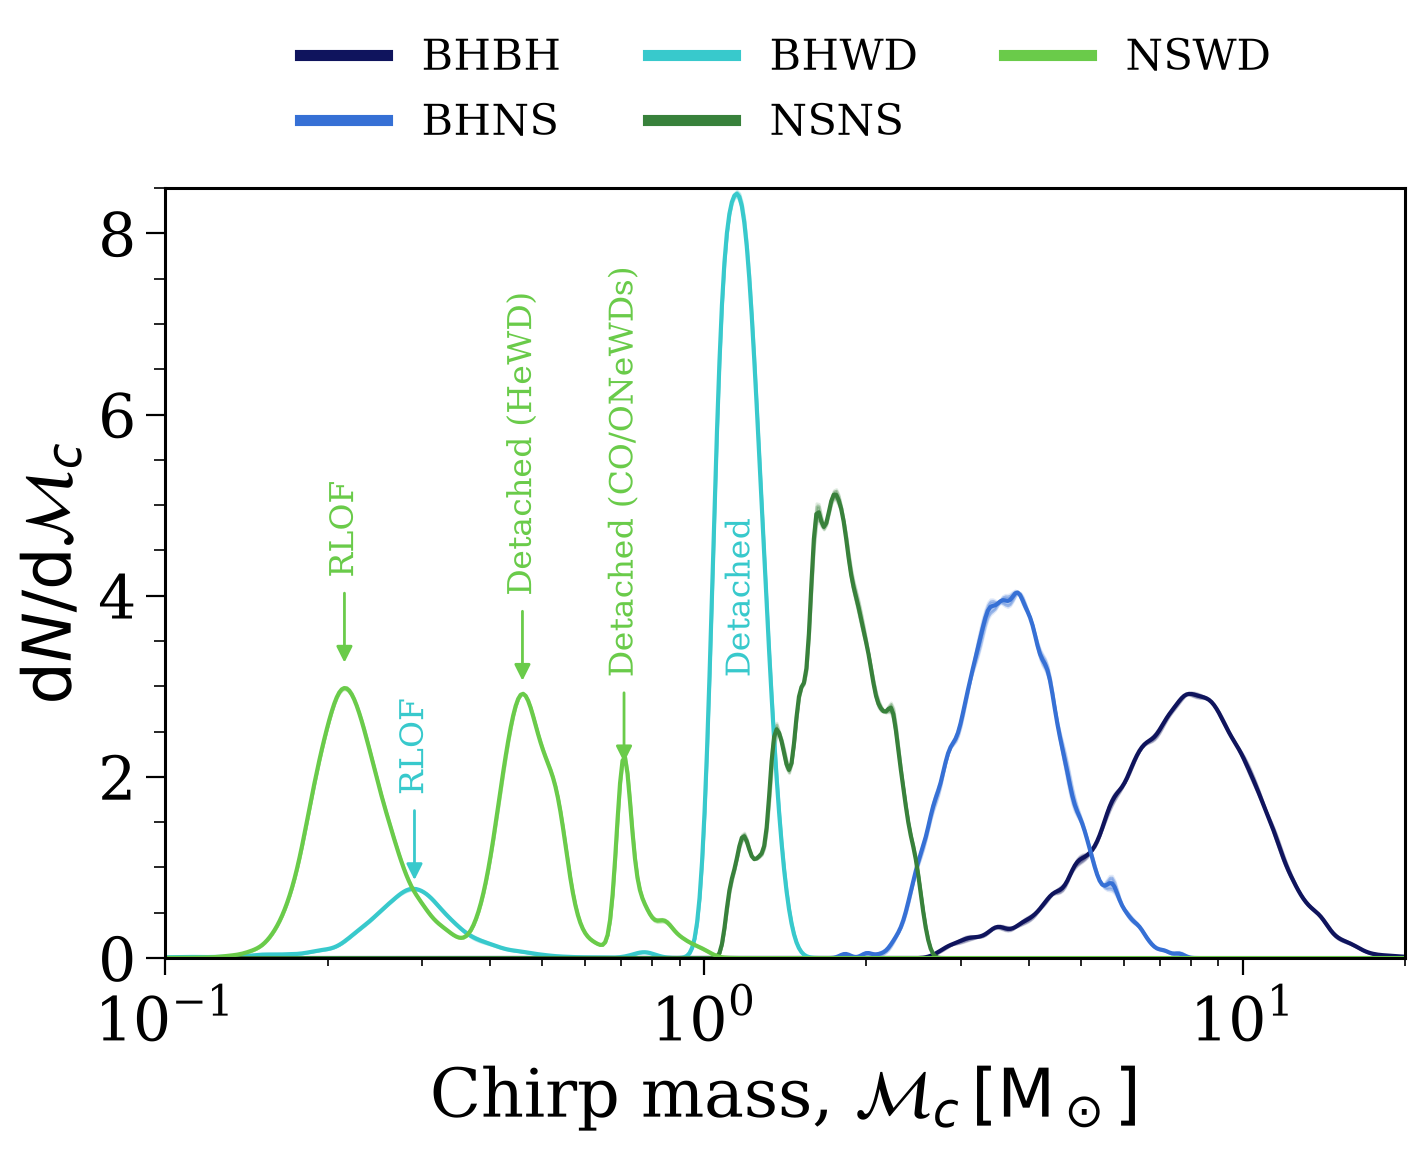

In [54]:
reload(plotting)

fig, ax = plt.subplots(figsize=(8, 5))

for dco_type in const.DCO_TYPES:
    s = lisa_sources[dco_type]
    w = lisa_pops[dco_type].bpp["weights"]
    # plt.hist(np.log10(s.m_c.value), bins=np.linspace(np.log10(0.1), np.log10(30), 200), weights=w, label=dco_type, histtype="step", lw=0.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.m_c.value), weights=w.values, ax=ax, x_min=np.log10(0.1), x_max=np.log10(20),
        bootstraps=2, x_count=500, bw_adjust=0.65, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

    # total = np.sum(w)
    # rlof_mask = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr
    # if rlof_mask.sum() > 0:
    #     s = detectable_sources[dco_type][(detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7) & rlof_mask]
    #     w = detectable_pops[dco_type].bpp[(detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7) & rlof_mask]["weights"]
    #     plotting.bootstrapped_kde_fast(
    #         variable=np.log10(s.m_c.value), weights=w.values, ax=ax, x_min=np.log10(0.1), x_max=np.log10(30), bootstraps=50, x_count=500, bw_adjust=0.5, color="black", label=dco_type,
    #         normalisation=np.sum(w) / total
    #     )

plotting.fake_log_axis(ax, axis="x")

handles, labels = ax.get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(4)
ax.legend(handles, labels, loc="lower center", ncol=3, fontsize=0.65*fs, bbox_to_anchor=(0.5, 1.005), frameon=False)

annotations = [
    (0.215, 3.2,  "RLOF", const.DCO_COLOURS["NSWD"]),
    (0.46, 3, "Detached (HeWD)", const.DCO_COLOURS["NSWD"]),
    (0.71, 2.1, "Detached (CO/ONeWDs)", const.DCO_COLOURS["NSWD"]),
    (0.29, 0.8, "RLOF", const.DCO_COLOURS["BHWD"]),
    (1.17, 2.1, "Detached", const.DCO_COLOURS["BHWD"]),
]

for x, y, text, color in annotations:
    ax.annotate(text, xy=(np.log10(x), y), xytext=(np.log10(x), y + 1), xycoords="data", ha='center', va="bottom",
                fontsize=0.5*fs, color=color, rotation=90,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="none") if text != "Detached" else None,
                arrowprops=dict(arrowstyle="-|>", color=color) if text != "Detached" else None)

ax.set(
    xlabel=r"Chirp mass, $\mathcal{M}_c \, [\rm {M_\odot}]$",
    ylabel=r"${\rm d}N / {\rm d} \mathcal{M}_c$",
    xlim=(-1, np.log10(20)),
    ylim=(0, 8.5),
    # yscale="log",
    # ylim=(1e-1, 2e1)
)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))

# plt.savefig("../plots/m_chirp_lisa.pdf", bbox_inches="tight")

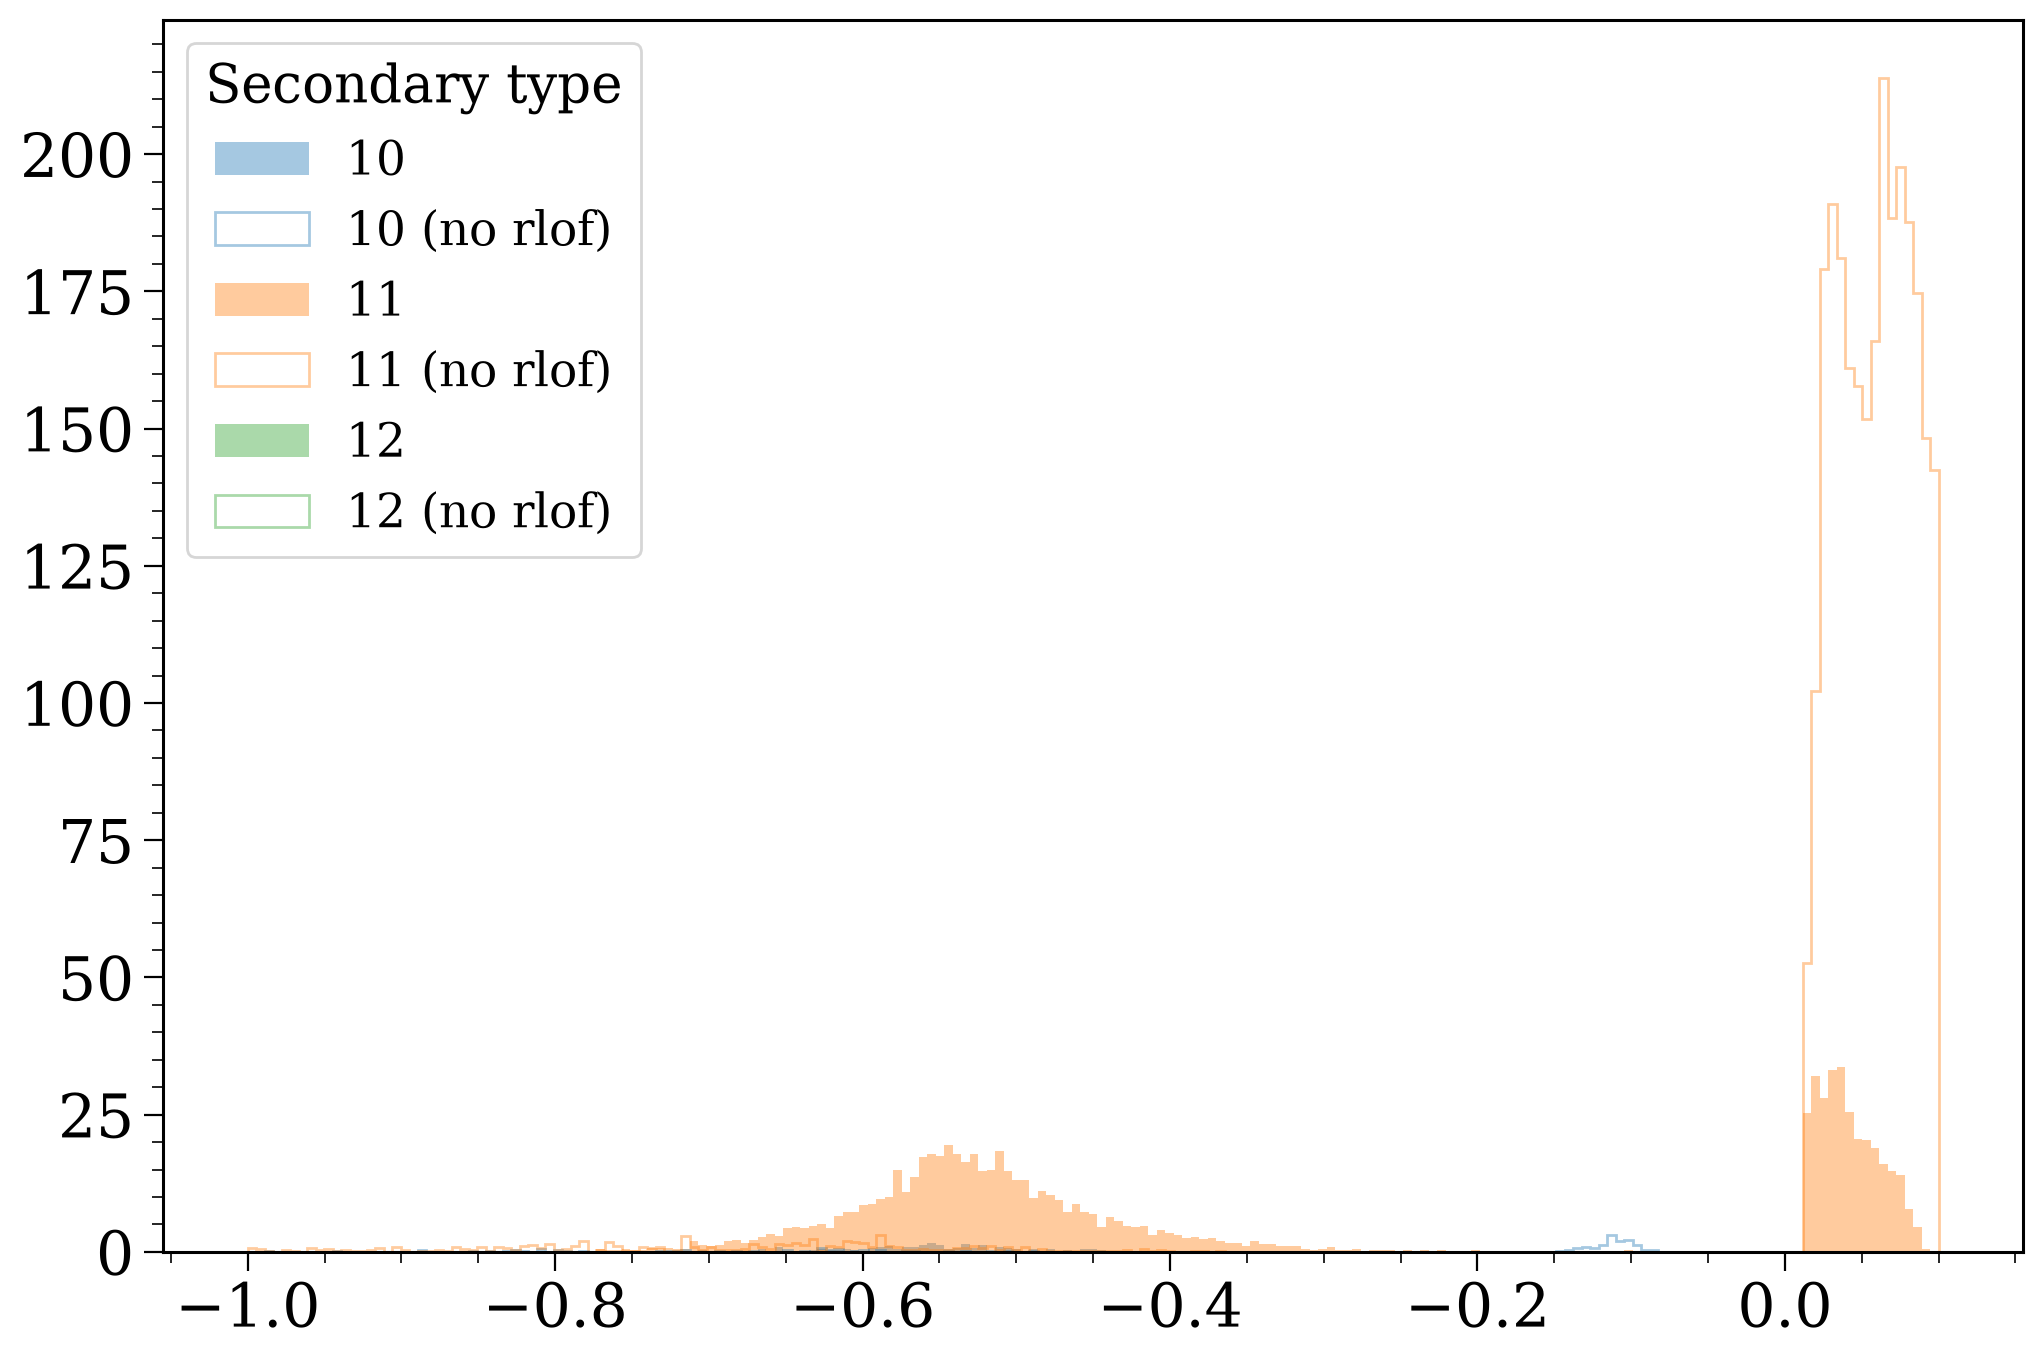

In [49]:
# THIS CELL PROVES WHICH GROUP IS WHICH

DT = "BHWD_pessimistic"

for i, kstar in enumerate([10, 11, 12]):
    mask = detectable_pops[DT].bpp["kstar_2"] == kstar
    mask &= detectable_pops[DT].bpp["snr_lisa_4yr_final_pos"] > 7

    rlof = detectable_pops[DT].initial_galaxy.tau > detectable_pops[DT].bpp["rlof_time"].values * u.Myr

    plt.hist(np.log10(detectable_sources[DT].m_c.value[mask & rlof]), weights=detectable_pops[DT].bpp["weights"][mask & rlof], bins=np.linspace(-1, 0.1, 200), alpha=0.4, label=kstar, color=f"C{i}")
    plt.hist(np.log10(detectable_sources[DT].m_c.value[mask & ~rlof]), weights=detectable_pops[DT].bpp["weights"][mask & ~rlof], bins=np.linspace(-1, 0.1, 200), alpha=0.4, label=f"{kstar} (no rlof)", histtype="step", color=f"C{i}")
    # plt.hexbin(s.m_c, detectable_pops["NSWD"].bpp["kstar_2"][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7], bins="log", xscale="log")
plt.legend(title="Secondary type")

# Mega source plot

In [25]:
plain_sfh = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version="v2"))
plain_sfh.sample(500000)

BHWD has 1.00 of sources with e == 0, not plotting
NSWD has 1.00 of sources with e == 0, not plotting


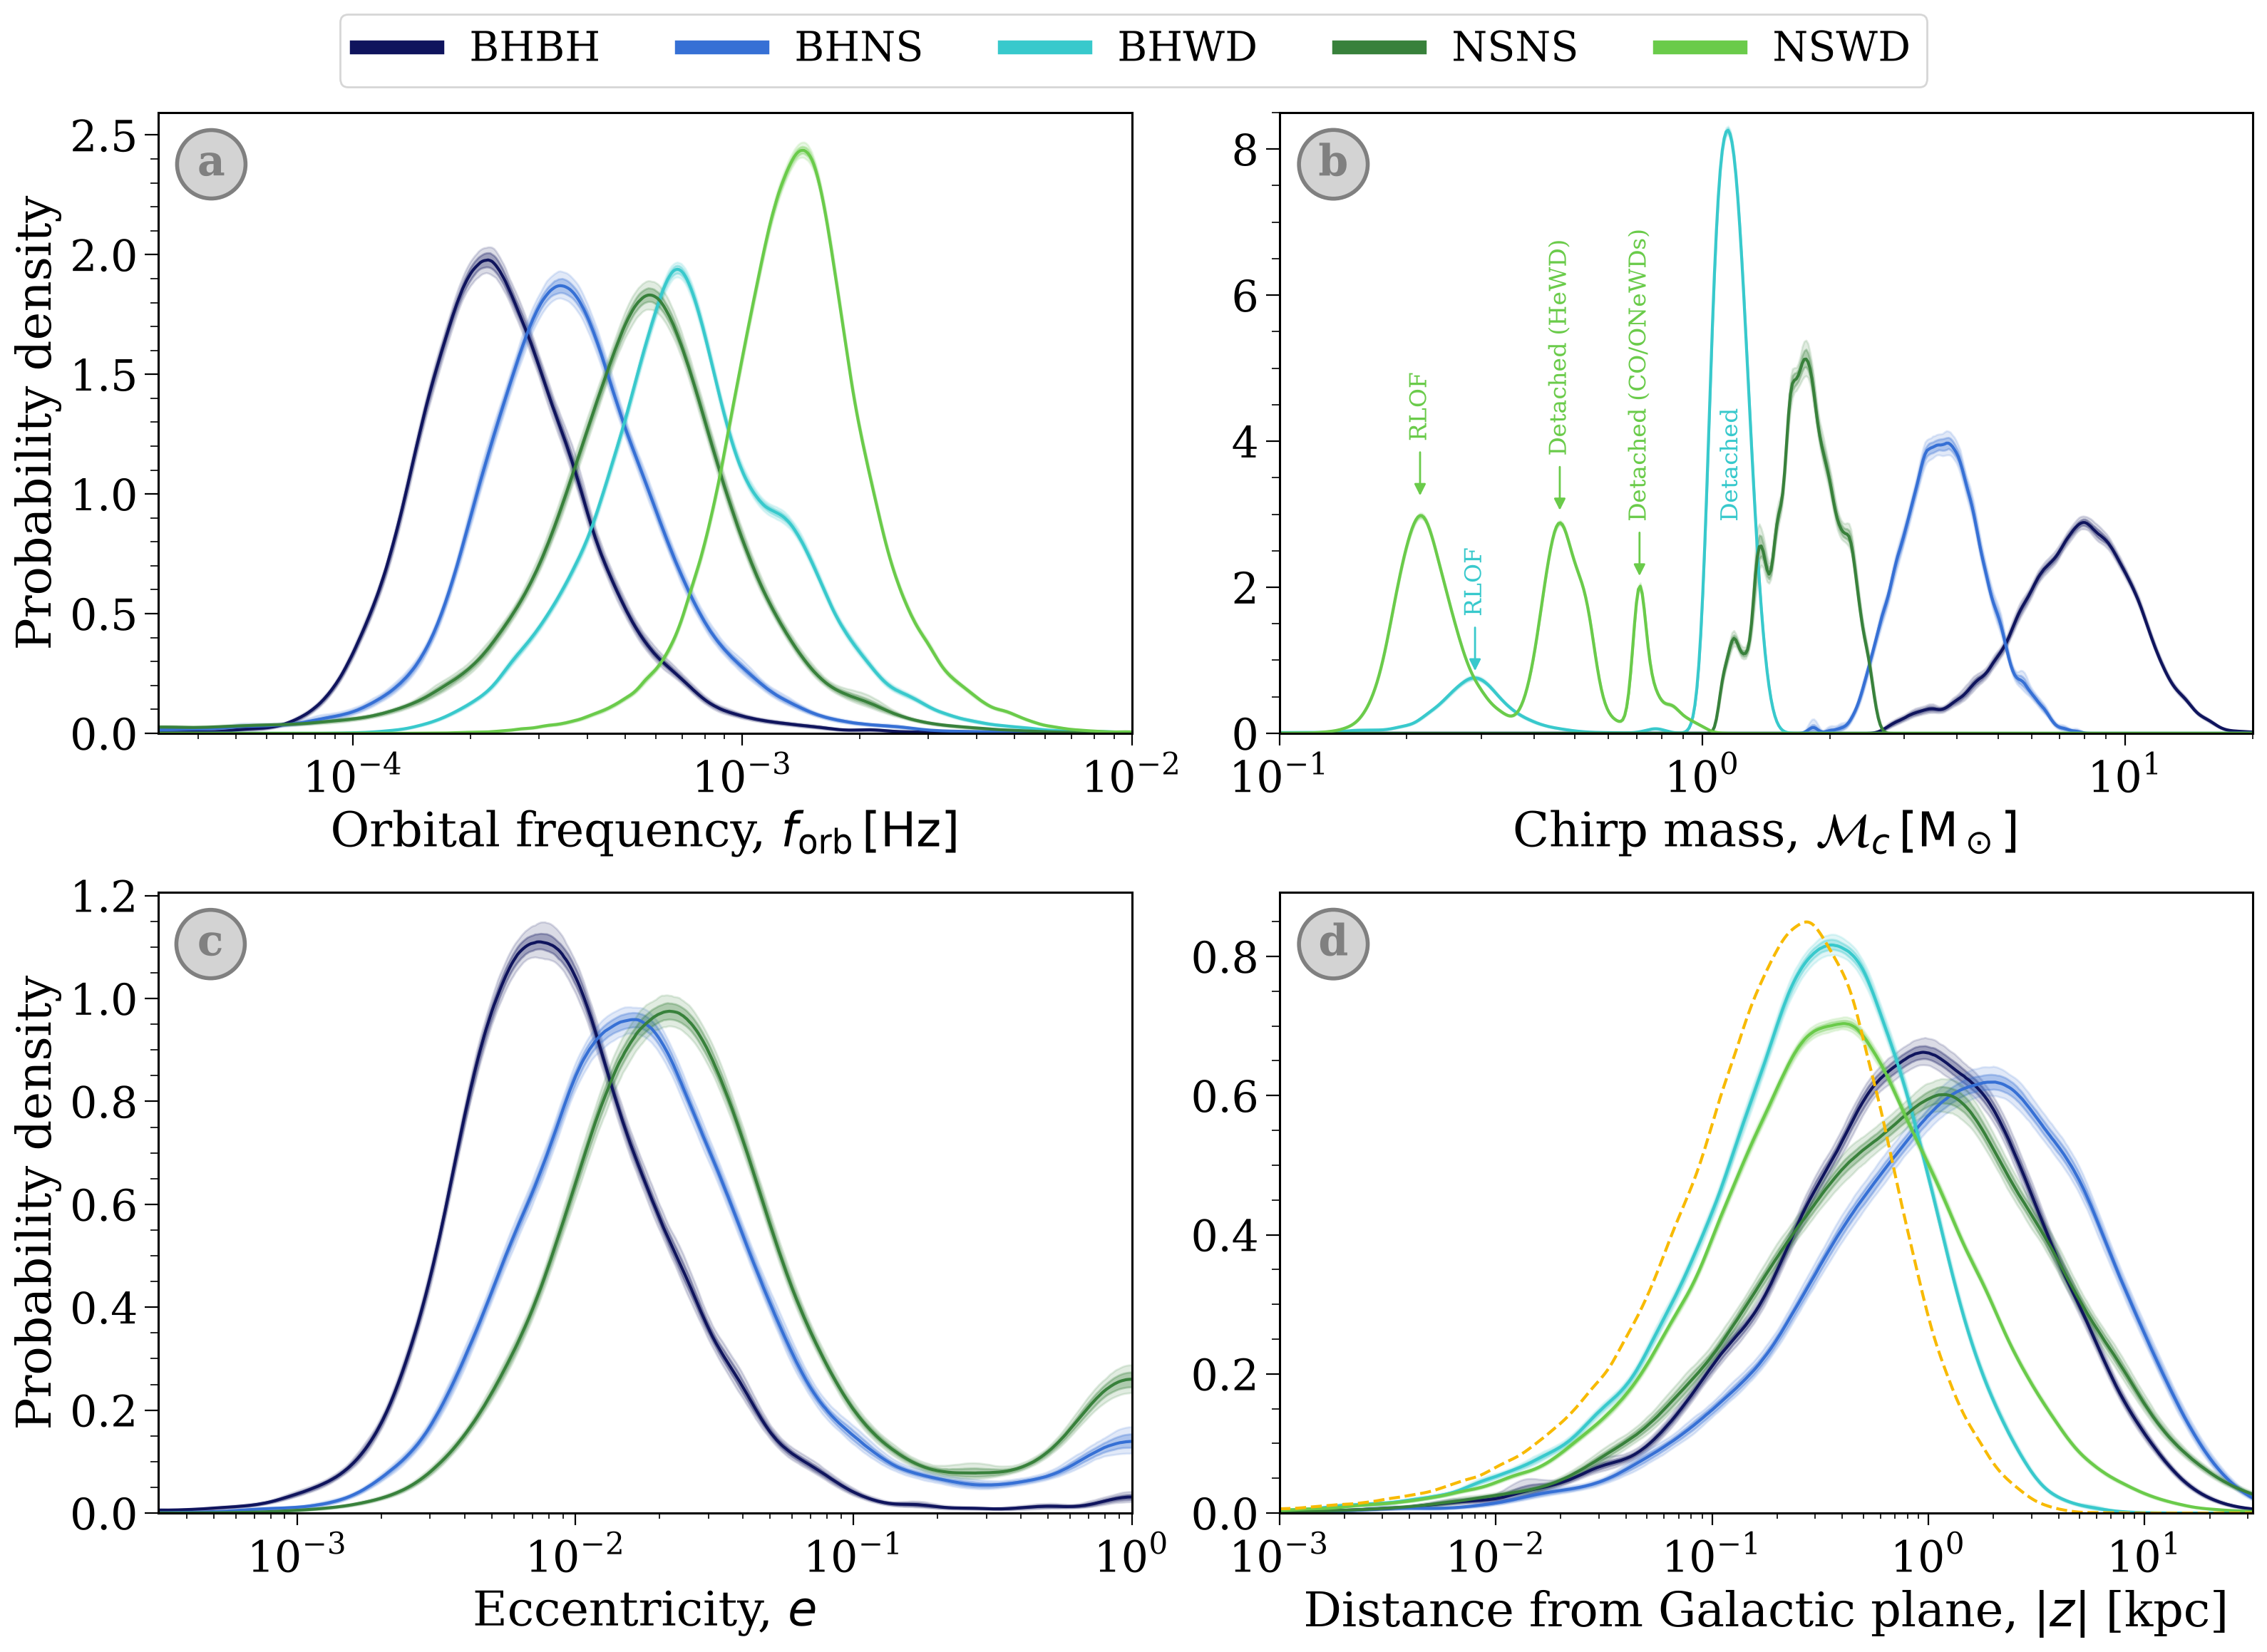

In [60]:
reload(plotting)
fig, axes = plt.subplots(2, 2, figsize=(16, 11), layout="tight")

N_BOOT = 500

# inset_ax = axes[0, 1].inset_axes([0.575, 0.575, 0.4, 0.4])

for dco_type in const.DCO_TYPES:
    s = lisa_sources[dco_type]#detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    w = lisa_pops[dco_type].bpp["weights"]

    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.f_orb.value), weights=w.values, ax=axes[0, 0], x_min=-4.5, x_max=-2, x_count=500,
        bootstraps=N_BOOT, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.m_c.value), weights=w.values, ax=axes[0, 1], x_min=np.log10(0.1), x_max=np.log10(20),
        bootstraps=N_BOOT, x_count=500, bw_adjust=0.75, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

    #z_vals = detectable_pops[dco_type].final_pos[:, 2].value[detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    z_vals = lisa_pops[dco_type].final_pos[:, 2].value
    # plotting.bootstrapped_kde_fast(
    #     variable=np.abs(z_vals), weights=w.values, ax=axes[1, 1], lower_bound=0, x_min=0, x_max=10, x_count=500, bootstraps=N_BOOT, color=const.DCO_COLOURS[dco_type], label=dco_type
    # )
    plotting.bootstrapped_kde_fast(
        variable=np.log10(np.abs(z_vals)), weights=w.values, ax=axes[1, 1], x_min=-3, x_max=1.5, x_count=500, bootstraps=N_BOOT, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

    circ = s.ecc == 0
    f_circ = np.sum(w[circ]) / np.sum(w)
    if f_circ > 0.9:
        print(f"{dco_type} has {f_circ:.2f} of sources with e == 0, not plotting")
        continue
    
    elif f_circ > 0.01:
        print(f"Warning that {dco_type} has {f_circ:.2f} of sources with e == 0, plotting anyway")
    # plt.hist(np.log10(s.ecc), bins=np.linspace(-4, 0, 100), weights=w, label=dco_type, histtype="step", lw=2.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(s.ecc[~circ]), weights=w.values[~circ], ax=axes[1, 0], upper_bound=0, x_min=-3.5, x_max=0, x_count=500,
        bootstraps=N_BOOT, color=const.DCO_COLOURS[dco_type], label=dco_type
    )

# plotting.bootstrapped_kde_fast(
#     variable=np.abs(plain_sfh.z.value), weights=np.ones_like(plain_sfh.z.value), ax=axes[1, 1],
#     lower_bound=0, x_min=0, x_max=10, x_count=500, bootstraps=1, color="#F8BA00", label="SFH",
#     fill_uncertainties=False, linestyle="--"
# )
plotting.bootstrapped_kde_fast(
    variable=np.log10(np.abs(plain_sfh.z.value)), weights=np.ones_like(plain_sfh.z.value), ax=axes[1, 1],
    x_min=-3, x_max=1.5, x_count=500, bootstraps=1, color="#F8BA00", label="SFH",
    fill_uncertainties=False, linestyle="--"
)

plotting.fake_log_axis(axes[0, 0], axis="x")
plotting.fake_log_axis(axes[0, 1], axis="x")
plotting.fake_log_axis(axes[1, 0], axis="x")
plotting.fake_log_axis(axes[1, 1], axis="x")

for ax in axes.flatten():
    ax.set_ylim(0, None)
for ax in axes[:, 0]:
    ax.set_ylabel("Probability density")

axes[0, 0].set(
    xlabel=r"Orbital frequency, $f_{\rm orb} \, [\rm Hz]$",
    xlim=(-4.5, -2),
)

# annotations = [
#     (0.215, 3.7,  "RLOF", const.DCO_COLOURS["NSWD"]),
#     (0.47, 2, "Detached (HeWD)", const.DCO_COLOURS["NSWD"]),
#     (0.75, 2.3, "Detached (CO/ONeWDs)", const.DCO_COLOURS["NSWD"]),
#     (0.33, 2.5, "RLOF", const.DCO_COLOURS["BHWD"]),
#     (1.5, 2.7, "Detached", const.DCO_COLOURS["BHWD"]),
# ]
annotations = [
    (0.215, 3.2,  "RLOF", const.DCO_COLOURS["NSWD"]),
    (0.46, 3, "Detached (HeWD)", const.DCO_COLOURS["NSWD"]),
    (0.71, 2.1, "Detached (CO/ONeWDs)", const.DCO_COLOURS["NSWD"]),
    (0.29, 0.8, "RLOF", const.DCO_COLOURS["BHWD"]),
    (1.17, 2.1, "Detached", const.DCO_COLOURS["BHWD"]),
]
for x, y, text, color in annotations:
    axes[0, 1].annotate(text, xy=(np.log10(x), y), xytext=(np.log10(x), y + 0.8), xycoords="data", ha='center', va="bottom",
                fontsize=0.5*fs, color=color, rotation=90,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="none") if text != "Detached" else None,
                arrowprops=dict(arrowstyle="-|>", color=color) if text != "Detached" else None)

axes[0, 1].set(
    xlabel=r"Chirp mass, $\mathcal{M}_c \, [\rm {M_\odot}]$",
    xlim=(-1, np.log10(20)),
    ylim=(0, 8.5),
)
axes[0, 1].yaxis.set_minor_locator(plt.MultipleLocator(0.5))

# inset_ax.set(
#     xlim=(-1, np.log10(30)),
# )
# inset_ax.axhline(7, color="k", ls="--", lw=0.5)
# inset_ax.tick_params(axis="both", which="both", labelsize=0.5*fs)
# inset_ax.yaxis.set_minor_locator(plt.MultipleLocator(1))

axes[1, 0].set(
    xlabel=r"Eccentricity, $e$",
    xlim=(-3.5, 0),
)

axes[1, 1].set(
    xlabel=r"Distance from Galactic plane, $|z|$ [kpc]",
    xlim=(-3, 1.5),
    # yscale="log",
    # ylim=(3e-3, 1e1)
)

handles, labels = axes[0, 0].get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(7)
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=0.85*fs, bbox_to_anchor=(0.5, 0.99))

for letter, ax in zip("abcd", axes.flatten()):
    ax.annotate(letter, xy=(0.04, 0.925), xycoords="axes fraction", ha='left', va="center_baseline", fontsize=0.9*fs, color="grey", fontweight="bold",
                bbox=dict(boxstyle="circle", facecolor="lightgrey", edgecolor="grey", linewidth=2))

plt.savefig("../plots/dco_properties.pdf", bbox_inches="tight")
plt.show()

BHBH [0.03512549 0.51459295 4.39582539] 1.160953314864855
BHNS [0.052644   0.90063566 7.35557888] 2.0137244286116287
BHWD [0.02960323 0.37378954 1.88183902] 0.5973710856862318
NSNS [0.01948563 0.29482762 4.83847771] 1.3142356266107769
NSWD [0.01822072 0.23723044 2.48033386] 0.6542824111511674


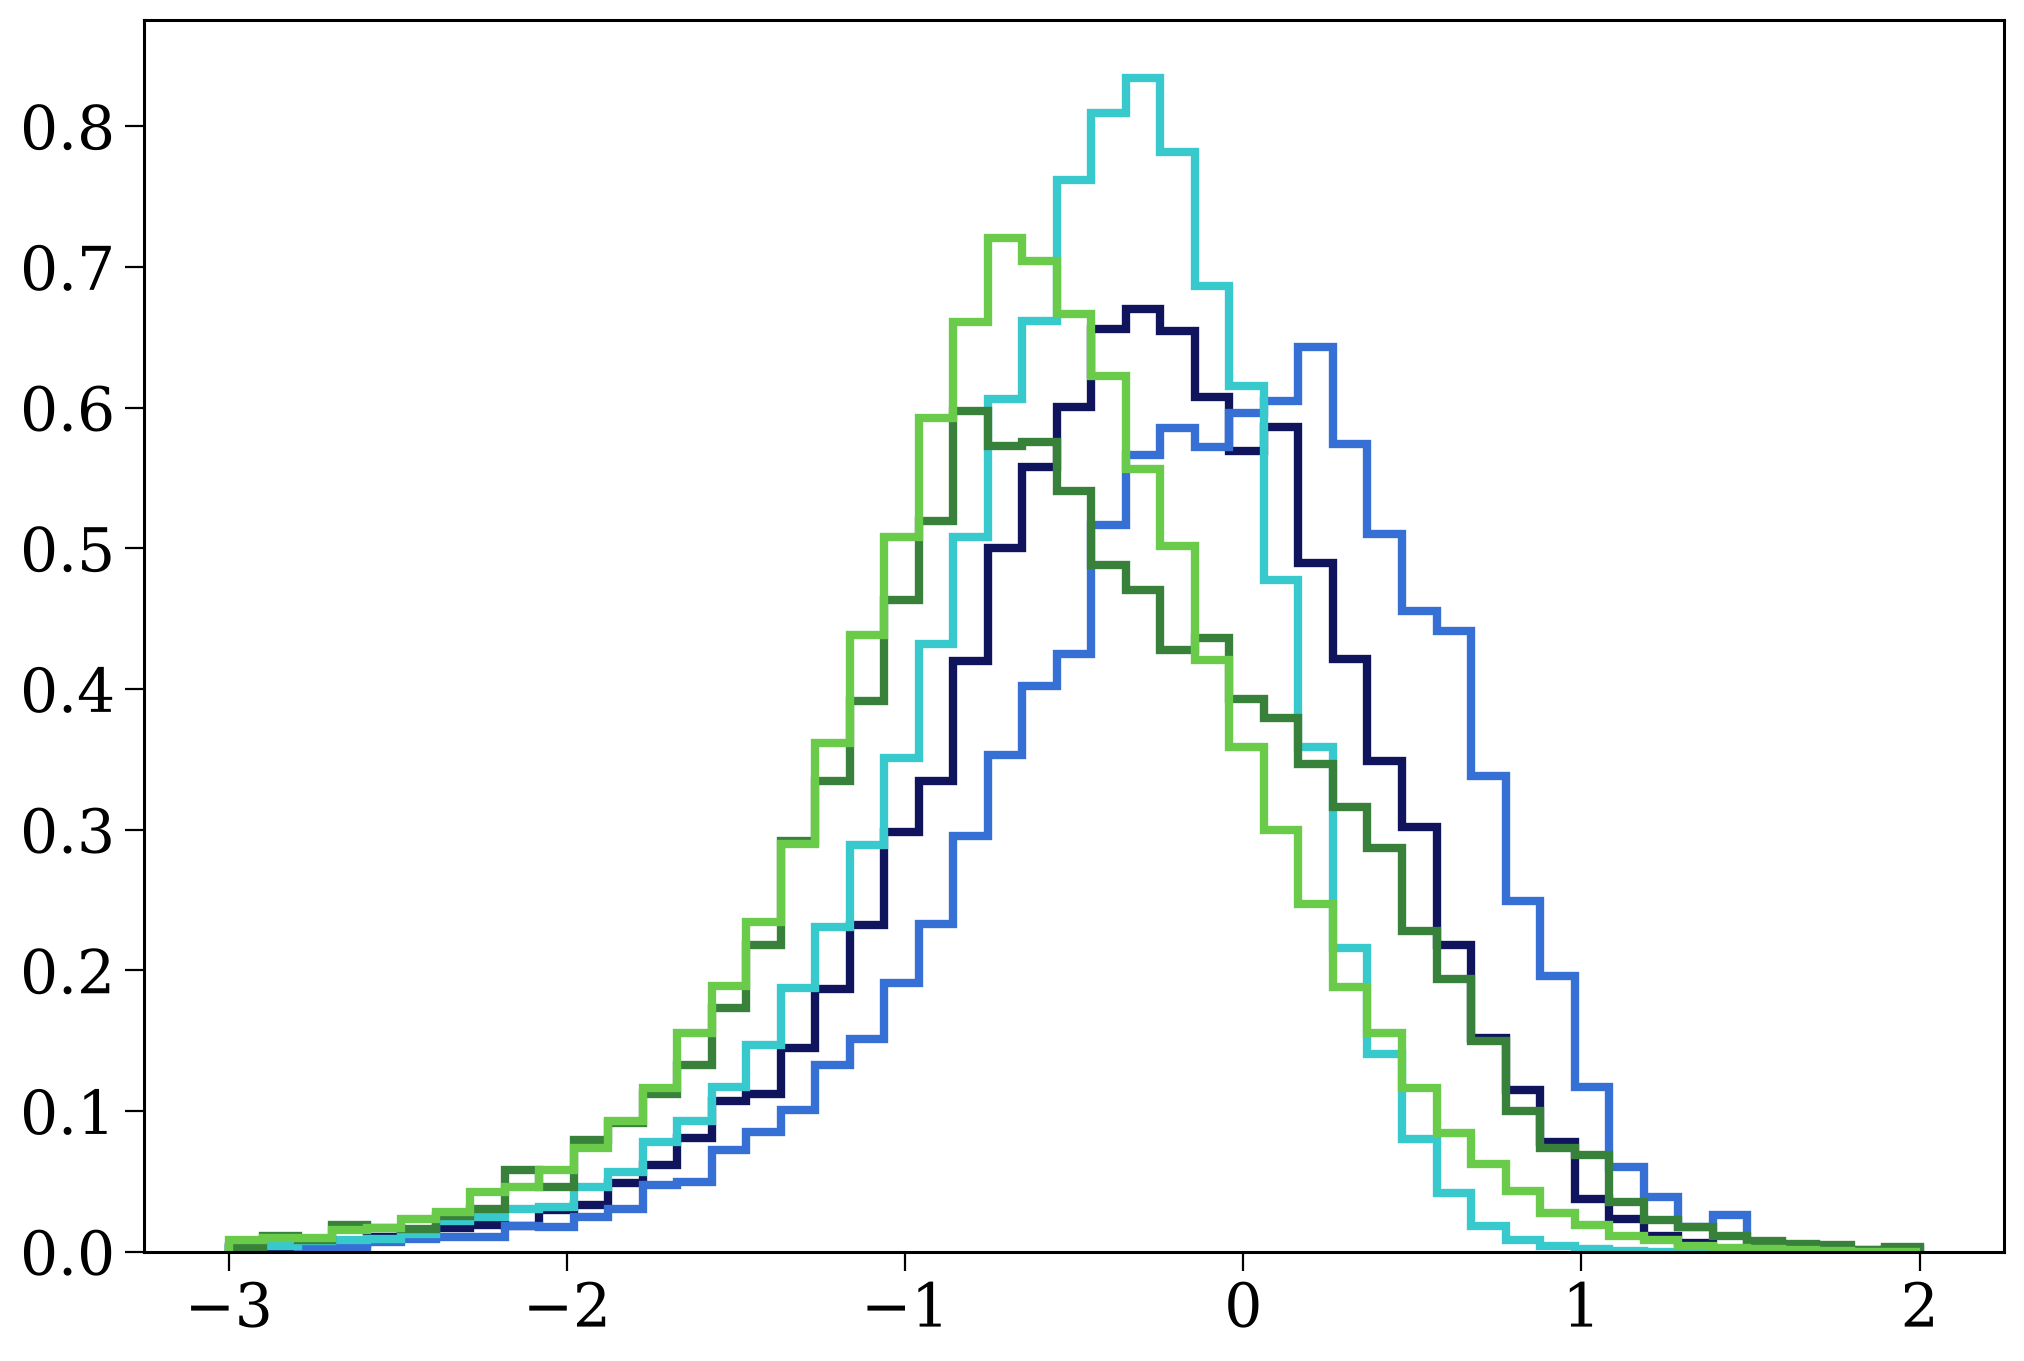

In [21]:
for dco_type in const.DCO_TYPES:
    w = lisa_4yr_pops[dco_type].initC["weights"]
    z_vals = detectable_pops[dco_type].final_pos[:, 2].value[detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]

    # plt.hist(np.abs(z_vals), weights=w, bins=np.linspace(0, 10, 50), density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step")
    print(dco_type, np.percentile(np.abs(z_vals), [5, 50, 95], weights=w, method="inverted_cdf"), np.average(np.abs(z_vals), weights=w))
    plt.hist(np.log10(np.abs(z_vals)), weights=w, bins=np.linspace(-3, 2, 50), density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step", lw=3)

# plt.yscale("log")

In [ ]:
detectable_pops["BHBH"].get_final_mw_skycoord

In [36]:
len(detectable_pops[dco_type].final_pos)

108838

In [31]:
detectable_pops[dco_type].get_final_mw_skycoord()

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in kpc
    [( 17.8893414 ,   3.66658083, -0.88960363),
     (-19.03934428,  -1.87703172,  7.73851757),
     ( 16.01863457, -13.77357759, -1.90869224), ...,
     ( -2.28531079,   0.70949855,  0.21228655),
     (  3.31164964,  -1.71002892,  0.32042868),
     ( -1.60606433,  -0.23087841,  0.07017832)]
 (v_x, v_y, v_z) in km / s
    [( -40.31791445,  212.50650394,   -3.6823464 ),
     (-103.15906116, -181.82983966,  -63.55158206),
     ( 172.12123778,  118.83442663,  -68.11670839), ...,
     (-228.39226717, -205.26830957,   18.37637657),
     (  22.38740722,  284.09727801,  -35.73644234),
     ( -67.62669285, -102.20743268, -245.79824696)]>

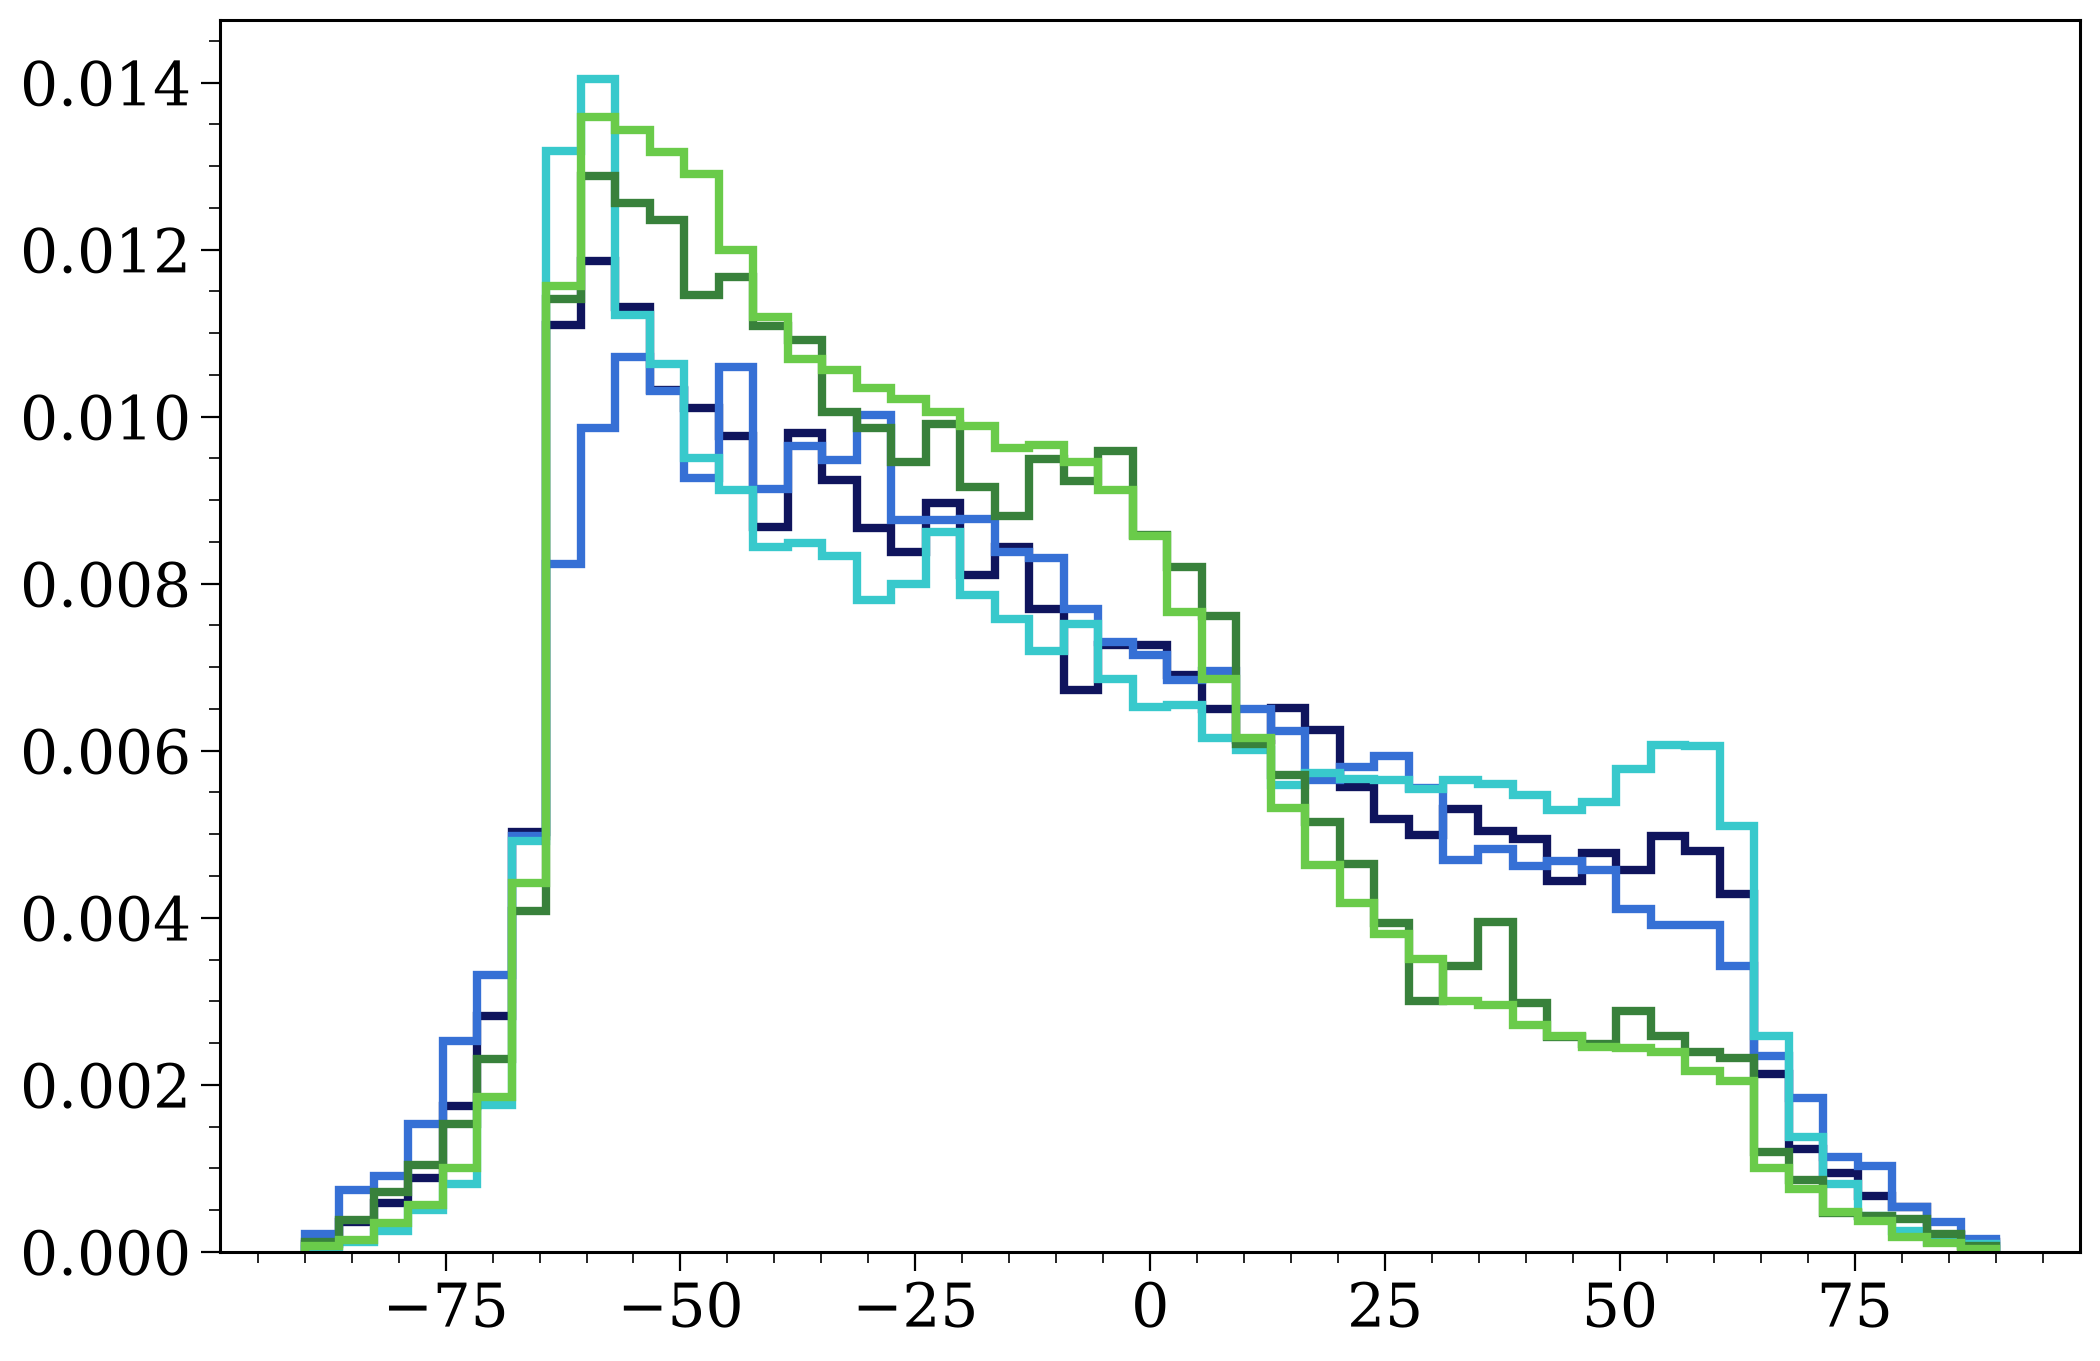

In [46]:
for dco_type in const.DCO_TYPES:
    w = lisa_4yr_pops[dco_type].initC["weights"]
    coords = detectable_pops[dco_type].get_final_mw_skycoord()[detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]

    # plt.hist(coords.icrs.ra.deg, weights=w, bins=np.linspace(0, 360, 50), density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step", lw=3)
    plt.hist(coords.icrs.dec.deg, weights=w, bins=np.linspace(-90, 90, 50), density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step", lw=3)

plt.show()

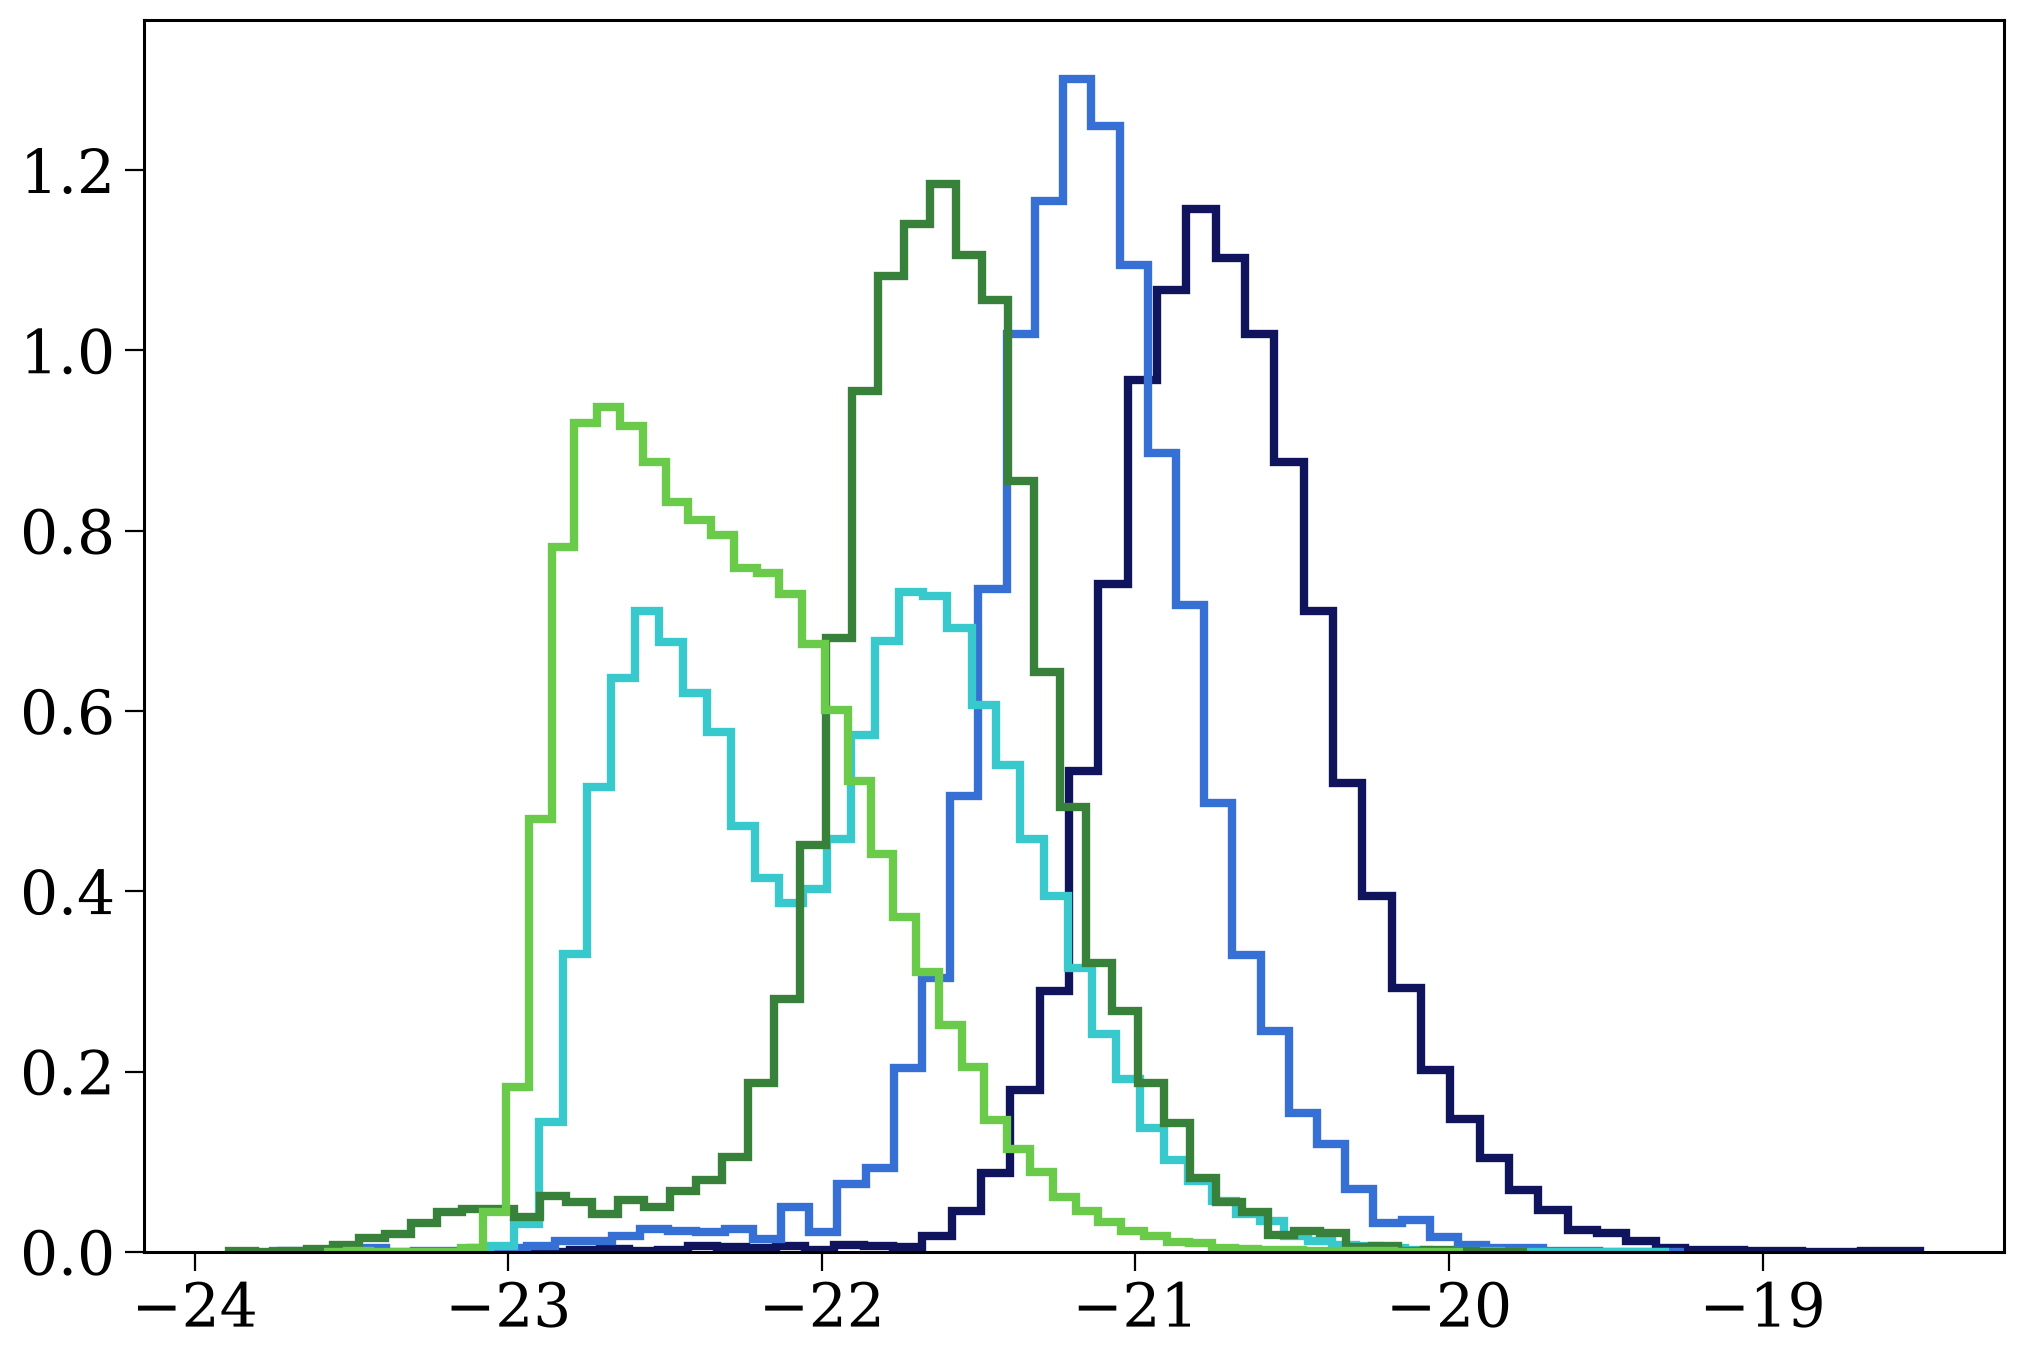

In [44]:
for dco_type in const.DCO_TYPES:
    w = lisa_4yr_pops[dco_type].initC["weights"]
    h_c = lisa_4yr_sources[dco_type].get_h_0_n(harmonics=[2])

    # plt.hist(coords.icrs.ra.deg, weights=w, bins=np.linspace(0, 360, 50), density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step", lw=3)
    plt.hist(np.log10(h_c.flatten()), weights=w, bins=50, density=True, label=dco_type, color=const.DCO_COLOURS[dco_type], histtype="step", lw=3)

plt.show()